# DC Mosquito Predictor

## Packages

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.in1d = np.isin
from rasterio.crs import CRS
from pysheds.grid import Grid
import rasterio
from pyproj import Transformer
import time
import folium
from IPython.display import display
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report, roc_auc_score, recall_score, precision_score, roc_curve
from sklearn.dummy import DummyClassifier
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
import joblib

In [2]:
RECOMPUTE_TWI = False  # set to True only if you need to rerun from scratch

## Load & Clean Trap Site data

In [3]:
# Load the mosquito trap data and keep a copy of the original DataFrame
trap_df = pd.read_csv("Mosquito_Trap_Sites.csv")
trap_df_original = trap_df.copy()

In [4]:
trap_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2023 entries, 0 to 2022
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   X                 2023 non-null   float64
 1   Y                 2023 non-null   float64
 2   TRAPTYPE          2023 non-null   str    
 3   ATTRACTANTSUSED   2023 non-null   str    
 4   TRAPID            2023 non-null   str    
 5   ADDRESS           2023 non-null   str    
 6   TOWN              2023 non-null   str    
 7   STATE             2023 non-null   str    
 8   COUNTY            2023 non-null   str    
 9   TRAPSITE          2023 non-null   str    
 10  TRAPSET           2023 non-null   str    
 11  SETTIMEOFDAY      2023 non-null   str    
 12  TRAPCOLLECT       2023 non-null   str    
 13  COLLECTTIMEOFDAY  2023 non-null   str    
 14  GENUS             2023 non-null   str    
 15  SPECIES           2023 non-null   str    
 16  LIFESTAGE         2023 non-null   str    
 17  EGGSCO

### y/n counts

In [5]:
# calculate percentage 'No' vs 'Yes' for columns in trap_df
collect_cols = ['EGGSCOLLECTED', 'LARVAECOLLECTED', 'PUPAECOLLECTED', 'UNKNOWNCOLLECTED']

rows = []
for c in collect_cols:
    s = trap_df[c].fillna('Missing').astype(str)
    total = len(s)
    yes_count = (s == 'Yes').sum()
    no_count = (s == 'No').sum()
    rows.append({
        'column': c,
        'yes_count': yes_count,
        'yes_pct': round(yes_count / total * 100, 2),
        'no_count': no_count,
        'no_pct': round(no_count / total * 100, 2),
        'other_count': total - yes_count - no_count,
    })

pct_df = pd.DataFrame(rows).set_index('column')
print(pct_df)

                  yes_count  yes_pct  no_count  no_pct  other_count
column                                                             
EGGSCOLLECTED             0      0.0      2023   100.0            0
LARVAECOLLECTED           0      0.0      2023   100.0            0
PUPAECOLLECTED            4      0.2      2019    99.8            0
UNKNOWNCOLLECTED          0      0.0         0     0.0         2023


### Drop unecessary cols

In [6]:
# Drop unnecessary columns from trap_df
cols_to_drop = ['EGGSCOLLECTED', 'LARVAECOLLECTED', 'PUPAECOLLECTED','UNKNOWNCOLLECTED', # Little to no data
                'X', 'Y','GIS_ID', 'SE_ANNO_CAD_DATA', 'GLOBALID', 'CREATED', 'EDITED', 'OBJECTID', 'TRAPID', 'TRAPSET', 'REPORTDATE', 'ADDRESS', # Not relevant for prediction 
                'LIFESTAGE', 'TOWN', 'STATE', 'COUNTY', # Only 1 value for each, so not useful for prediction
                'GENUS', 'SPECIES', 'TRAPTYPE', 'ATTRACTANTSUSED', 'MALESCOLLECTED', 'TRAPSITE', 'SETTIMEOFDAY', 'DATE'] # Out of scope for this project
trap_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# confirm
trap_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2023 entries, 0 to 2022
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TRAPCOLLECT       2023 non-null   str    
 1   COLLECTTIMEOFDAY  2023 non-null   str    
 2   FEMALESCOLLECTED  2023 non-null   int64  
 3   LATITUDE          2023 non-null   float64
 4   LONGITUDE         2023 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 79.2 KB


### Check Categoricals

In [7]:
# Check unique values for categorical columns in trap_df
# This code is largely unecessary after removing unnecessary columns from trap_df
cols = ['TRAPTYPE', 'ATTRACTANTSUSED', 'TRAPID', 'ADDRESS', 'TOWN', 'STATE', 'COUNTY',
    'TRAPSITE', 'COLLECTTIMEOFDAY', 'GENUS', 'SPECIES', 'LIFESTAGE', 'LATITUDE', 'LONGITUDE']

for c in cols:
    if c in trap_df.columns:
        vals = trap_df[c].dropna().astype(str).unique()
        vals_sorted = sorted(vals)
        print(f"{c} ({len(vals_sorted)} unique):")
        for v in vals_sorted:
            print(f"  - {v}")
    else:
        print(f"{c}: column not found in trap_df")
    print()

TRAPTYPE: column not found in trap_df

ATTRACTANTSUSED: column not found in trap_df

TRAPID: column not found in trap_df

ADDRESS: column not found in trap_df

TOWN: column not found in trap_df

STATE: column not found in trap_df

COUNTY: column not found in trap_df

TRAPSITE: column not found in trap_df

COLLECTTIMEOFDAY (2 unique):
  - Afternoon
  - Morning

GENUS: column not found in trap_df

SPECIES: column not found in trap_df

LIFESTAGE: column not found in trap_df

LATITUDE (38 unique):
  - 38.820636
  - 38.831034
  - 38.864642
  - 38.8731
  - 38.874409
  - 38.874658
  - 38.875372
  - 38.884385
  - 38.887646
  - 38.887771
  - 38.888979
  - 38.890913
  - 38.891675
  - 38.891722
  - 38.898014
  - 38.906416
  - 38.907205
  - 38.907725
  - 38.913193
  - 38.914005
  - 38.914656
  - 38.920896
  - 38.921453
  - 38.927132
  - 38.931573
  - 38.937768
  - 38.938009
  - 38.939464
  - 38.945614
  - 38.952145
  - 38.954471
  - 38.95682
  - 38.956854
  - 38.971088
  - 38.972853
  - 38.972854


### Convert Datetime

In [8]:
# Convert date columns to datetime
trap_df['TRAPCOLLECT'] = pd.to_datetime(trap_df['TRAPCOLLECT']).dt.tz_localize(None).dt.normalize()
trap_df['TRAPCOLLECT'].dtype

dtype('<M8[us]')

In [9]:
# Count nulls per column and percent of total rows
null_counts = trap_df.isnull().sum()
null_pct = (null_counts / len(trap_df) * 100).round(2)

null_df = pd.DataFrame({
    'null_count': null_counts,
    'null_pct': null_pct
}).sort_values('null_count', ascending=False)

print(null_df)
print("\nTotal null values in DataFrame:", null_counts.sum())

                  null_count  null_pct
TRAPCOLLECT                0       0.0
COLLECTTIMEOFDAY           0       0.0
FEMALESCOLLECTED           0       0.0
LATITUDE                   0       0.0
LONGITUDE                  0       0.0

Total null values in DataFrame: 0


In [10]:
# create a numeric SITEID for each unique (LATITUDE, LONGITUDE) pair
# Addresses not unique due to mispelling. Lat Long should be used for unique site identification instead.
coords = trap_df[['LATITUDE', 'LONGITUDE']].apply(lambda r: (r['LATITUDE'], r['LONGITUDE']), axis=1)  # Series of tuples
codes, uniques = pd.factorize(coords)  # now works with a Series
trap_df['SITEID'] = codes.astype(int) + 1  # make SITEID start at 1

# create a mapping table of SITEID -> LATITUDE, LONGITUDE
site_map = pd.DataFrame(uniques.tolist(), columns=['LATITUDE', 'LONGITUDE'])
site_map['SITEID'] = range(1, len(site_map) + 1)

print(f"Assigned {site_map.shape[0]} unique SITEID(s)")
print(site_map.head())
trap_df.head()

Assigned 40 unique SITEID(s)
    LATITUDE  LONGITUDE  SITEID
0  38.985287 -77.038164       1
1  38.980316 -77.051943       2
2  38.972854 -77.052976       3
3  38.972853 -77.053002       4
4  38.971088 -77.029901       5


,TRAPCOLLECT,COLLECTTIMEOFDAY,FEMALESCOLLECTED,LATITUDE,LONGITUDE,SITEID
0,2016-04-27,Morning,4,38.985287,-77.038164,1
1,2016-06-15,Morning,50,38.985287,-77.038164,1
2,2016-06-08,Morning,2,38.985287,-77.038164,1
3,2016-05-11,Afternoon,3,38.985287,-77.038164,1
4,2016-07-20,Morning,23,38.985287,-77.038164,1


In [11]:
# print min and max dates from TRAPCOLLECT column
min_date = trap_df['TRAPCOLLECT'].min()
max_date = trap_df['TRAPCOLLECT'].max()

print("Min TRAPCOLLECT:", min_date)
print("Max TRAPCOLLECT:", max_date)

Min TRAPCOLLECT: 2016-04-06 00:00:00
Max TRAPCOLLECT: 2018-10-31 00:00:00


## Load & Clean Weather Data

In [12]:
# Load the weather data and keep a copy of the original DataFrame
weather_df = pd.read_csv("Mosquito_Weather_NOAA.csv")
weather_df_original = weather_df.copy()

In [13]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  971 non-null    str    
 1   NAME     971 non-null    str    
 2   DATE     971 non-null    str    
 3   MDPR     1 non-null      float64
 4   PRCP     965 non-null    float64
 5   SNOW     923 non-null    float64
 6   SNWD     920 non-null    float64
 7   TMAX     959 non-null    float64
 8   TMIN     962 non-null    float64
 9   WESD     354 non-null    float64
 10  WT01     10 non-null     float64
 11  WT03     1 non-null      float64
 12  WT04     2 non-null      float64
 13  WT06     1 non-null      float64
 14  WT11     1 non-null      float64
dtypes: float64(12), str(3)
memory usage: 113.9 KB


In [14]:
weather_df.head()

,STATION,NAME,DATE,MDPR,PRCP,SNOW,SNWD,TMAX,TMIN,WESD,WT01,WT03,WT04,WT06,WT11
0,USC00186350,"NATIONAL ARBORETUM DC, MD US",2016-03-01,NaN,0.0,0.0,0.0,17.8,6.1,NaN,NaN,NaN,NaN,NaN,NaN
1,USC00186350,"NATIONAL ARBORETUM DC, MD US",2016-03-02,NaN,2.0,0.0,0.0,19.4,4.4,NaN,NaN,NaN,NaN,NaN,NaN
2,USC00186350,"NATIONAL ARBORETUM DC, MD US",2016-03-03,NaN,0.0,0.0,0.0,6.7,-3.3,NaN,NaN,NaN,NaN,NaN,NaN
3,USC00186350,"NATIONAL ARBORETUM DC, MD US",2016-03-04,NaN,2.5,30.0,25.0,6.1,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,USC00186350,"NATIONAL ARBORETUM DC, MD US",2016-03-05,NaN,0.0,0.0,0.0,5.6,1.1,0.0,NaN,NaN,NaN,NaN,NaN


### Keep necessary cols

In [15]:
# Keep only relevant weather columns
keep_cols = ['DATE', 'PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN']
weather_df = weather_df.loc[:, weather_df.columns.intersection(keep_cols)].copy()

weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    971 non-null    str    
 1   PRCP    965 non-null    float64
 2   SNOW    923 non-null    float64
 3   SNWD    920 non-null    float64
 4   TMAX    959 non-null    float64
 5   TMIN    962 non-null    float64
dtypes: float64(5), str(1)
memory usage: 45.6 KB


### Convert datetime

In [16]:
# Convert date column to datetime
weather_df['DATE'] = pd.to_datetime(weather_df['DATE'])
weather_df['DATE'].dtype
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    971 non-null    datetime64[us]
 1   PRCP    965 non-null    float64       
 2   SNOW    923 non-null    float64       
 3   SNWD    920 non-null    float64       
 4   TMAX    959 non-null    float64       
 5   TMIN    962 non-null    float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 45.6 KB


### Average daily temp

In [17]:
# create TAVG as the average of TMAX and TMIN
weather_df['TMAX'] = pd.to_numeric(weather_df['TMAX'], errors='coerce')
weather_df['TMIN'] = pd.to_numeric(weather_df['TMIN'], errors='coerce')
weather_df['TAVG'] = ((weather_df['TMAX'] + weather_df['TMIN']) / 2).round(2)

weather_df.head()

,DATE,PRCP,SNOW,SNWD,TMAX,TMIN,TAVG
0,2016-03-01,0.0,0.0,0.0,17.8,6.1,11.95
1,2016-03-02,2.0,0.0,0.0,19.4,4.4,11.90
2,2016-03-03,0.0,0.0,0.0,6.7,-3.3,1.70
3,2016-03-04,2.5,30.0,25.0,6.1,0.0,3.05
4,2016-03-05,0.0,0.0,0.0,5.6,1.1,3.35


In [18]:
weather_df.describe().T

,count,mean,min,25%,50%,75%,max,std
DATE,971,2017-06-30 14:36:27.435633,2016-03-01 00:00:00,2016-10-29 12:00:00,2017-06-30 00:00:00,2018-03-02 12:00:00,2018-10-31 00:00:00,NaN
PRCP,965.0,3.265803,0.0,0.0,0.0,1.5,121.9,9.274446
SNOW,923.0,0.255688,0.0,0.0,0.0,0.0,64.0,3.054398
SNWD,920.0,0.328261,0.0,0.0,0.0,0.0,76.0,3.710536
TMAX,959.0,21.794369,-7.2,14.15,23.3,30.0,37.2,9.70355
TMIN,962.0,11.258836,-13.3,2.925,12.2,20.0,27.2,9.412905
TAVG,957.0,16.526541,-10.0,8.9,17.75,25.0,31.95,9.378468


In [19]:
weather_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 971 entries, 0 to 970
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    971 non-null    datetime64[us]
 1   PRCP    965 non-null    float64       
 2   SNOW    923 non-null    float64       
 3   SNWD    920 non-null    float64       
 4   TMAX    959 non-null    float64       
 5   TMIN    962 non-null    float64       
 6   TAVG    957 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 53.2 KB


### Missing values

In [20]:
# count null/NaN in weather_df
null_counts = weather_df.isnull().sum()

null_df_weather = pd.DataFrame({
    'null_count': null_counts
}).sort_values('null_count', ascending=False)

print(null_df_weather)

      null_count
SNWD          51
SNOW          48
TAVG          14
TMAX          12
TMIN           9
PRCP           6
DATE           0


### Impute missing weather

In [21]:
weather_cols = ['PRCP', 'SNOW', 'SNWD', 'TMAX', 'TMIN', 'TAVG']
weather_df[weather_cols] = weather_df[weather_cols].ffill() # forward fill to handle missing values, assuming weather conditions are similar day to day

### Create Lagged Weather Features

In [22]:
weather_df = weather_df.sort_values('DATE')

for lag in [7, 14, 21]:
    weather_df[f'PRCP_lag{lag}d'] = weather_df['PRCP'].shift(lag)
    weather_df[f'TAVG_lag{lag}d'] = weather_df['TAVG'].shift(lag)

# Rolling averages
weather_df['PRCP_roll7']  = weather_df['PRCP'].rolling(7).mean()
weather_df['TAVG_roll7']  = weather_df['TAVG'].rolling(7).mean()
weather_df['TAVG_roll14'] = weather_df['TAVG'].rolling(14).mean()

### Merge Trap-Weather Datasets

In [23]:
merged_df = trap_df.merge(weather_df, left_on='TRAPCOLLECT', right_on='DATE', how='left')

In [24]:
print(merged_df.shape)
print(merged_df.isnull().sum())
assert merged_df['FEMALESCOLLECTED'].notna().all()

(2023, 22)
TRAPCOLLECT         0
COLLECTTIMEOFDAY    0
FEMALESCOLLECTED    0
LATITUDE            0
LONGITUDE           0
SITEID              0
DATE                0
PRCP                0
SNOW                0
SNWD                0
TMAX                0
TMIN                0
TAVG                0
PRCP_lag7d          0
TAVG_lag7d          0
PRCP_lag14d         0
TAVG_lag14d         0
PRCP_lag21d         0
TAVG_lag21d         0
PRCP_roll7          0
TAVG_roll7          0
TAVG_roll14         0
dtype: int64


## LiDAR TWI Topographic Wetness Index
TWI = ln(flow accumulation / tan(slope))
High TWI = flat, low-lying areas where water pools → prime mosquito breeding habitat. Low TWI = steep, well-drained slopes → poor habitat.

### Clip Raster - 0
Need to reduce memory usage by shrinking the search space

In [25]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
import geopandas as gpd
import numpy as np

tif_path = 'DTM.tif'
clipped_path = 'dtm_clipped.tif'

# Build a bounding box around your trap points with a small buffer
minx = merged_df['LONGITUDE'].min() - 0.02  # ~2km buffer
maxx = merged_df['LONGITUDE'].max() + 0.02
miny = merged_df['LATITUDE'].min()  - 0.02
maxy = merged_df['LATITUDE'].max()  + 0.02

print(f"Clipping to: {minx:.4f}, {miny:.4f}, {maxx:.4f}, {maxy:.4f}")

bbox = box(minx, miny, maxx, maxy)

with rasterio.open(tif_path) as src:
    # Reproject bbox to match raster CRS
    from pyproj import Transformer
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    x0, y0 = transformer.transform(minx, miny)
    x1, y1 = transformer.transform(maxx, maxy)
    bbox_proj = box(x0, y0, x1, y1)

    clipped, clipped_transform = mask(src, [bbox_proj], crop=True)
    clipped_meta = src.meta.copy()
    clipped_meta.update({
        "height": clipped.shape[1],
        "width":  clipped.shape[2],
        "transform": clipped_transform
    })

with rasterio.open(clipped_path, 'w', **clipped_meta) as dst:
    dst.write(clipped)

print(f"Clipped raster saved to {clipped_path}")
print(f"Original size: {rasterio.open(tif_path).shape}")
print(f"Clipped size:  {rasterio.open(clipped_path).shape}")

Clipping to: -77.1172, 38.8006, -76.9120, 39.0053
Clipped raster saved to dtm_clipped.tif
Original size: (24000, 19200)
Clipped size:  (22319, 17810)


### Compute and Save TWI - 1

In [26]:
tif_path = 'dtm_clipped.tif'

In [27]:
# --- Load the raster ---
grid = Grid.from_raster(tif_path)
dem  = grid.read_raster(tif_path)

In [28]:
t0 = time.time()

if RECOMPUTE_TWI:
    pit_filled = grid.fill_pits(dem)
    print(f"fill_pits done: {time.time()-t0:.0f}s")
    np.save('pit_filled.npy', np.array(pit_filled))
    print("Pit-filled DEM saved to pit_filled.npy")

    flooded = grid.fill_depressions(pit_filled)
    print(f"fill_depressions done: {time.time()-t0:.0f}s")
    np.save('flooded.npy', np.array(flooded))
    print("Flooded DEM saved to flooded.npy")

    inflated = grid.resolve_flats(flooded)
    print(f"resolve_flats done: {time.time()-t0:.0f}s")
    np.save('inflated.npy', np.array(inflated))
    print("Inflated DEM saved to inflated.npy")

    fdir = grid.flowdir(inflated)
    print(f"flowdir done: {time.time()-t0:.0f}s")
    np.save('fdir.npy', np.array(fdir))
    print("Flow direction saved to fdir.npy")

    accum = grid.accumulation(fdir)
    print(f"accumulation done: {time.time()-t0:.0f}s")
    np.save('accum.npy', np.array(accum))
    print("Flow accumulation saved to accum.npy")
else:
    pit_filled = np.load('pit_filled.npy')
    print("Loaded pit-filled DEM from pit_filled.npy")

    flooded = np.load('flooded.npy')
    print("Loaded flooded DEM from flooded.npy")

    inflated = np.load('inflated.npy')
    print("Loaded inflated DEM from inflated.npy")

    fdir = np.load('fdir.npy')
    print("Loaded flow direction from fdir.npy")

    accum = np.load('accum.npy')
    print("Loaded flow accumulation from accum.npy")

Loaded pit-filled DEM from pit_filled.npy
Loaded flooded DEM from flooded.npy
Loaded inflated DEM from inflated.npy
Loaded flow direction from fdir.npy
Loaded flow accumulation from accum.npy


In [29]:
# --- Slope ---
with rasterio.open(tif_path) as src:
    res = src.res[0]
    print(f"Pixel size: {src.res}")

dy, dx = np.gradient(np.array(dem), res)
slope  = np.sqrt(dx**2 + dy**2)

Pixel size: (1.0, 1.0)


In [ ]:
# --- TWI ---
if RECOMPUTE_TWI:
     # Avoid log(0) by adding a small constant to slope
     twi = np.log((accum + 1) / (slope + 0.001))
     np.save('twi.npy', np.array(twi))
     print("TWI computed and saved to twi.npy")
else:
    twi = np.load('twi.npy')
    print("Loaded TWI from twi.npy")

#np.save('twi.npy', twi)
print("TWI saved to twi.npy")

Loaded TWI from twi.npy
TWI saved to twi.npy


### Sample TWI at Trap Sites & Merge to merged_df - 2

In [31]:
# Load saved TWI (skips recomputing if kernel restarted)
twi = np.load('twi.npy')

def sample_array_buffered(arr, coords, transform, buffer_pixels=15):
    results = []
    for x, y in coords:
        col, row = ~transform * (x, y)
        row, col = int(row), int(col)

        r0 = max(row - buffer_pixels, 0)
        r1 = min(row + buffer_pixels, arr.shape[0])
        c0 = max(col - buffer_pixels, 0)
        c1 = min(col + buffer_pixels, arr.shape[1])

        window = arr[r0:r1, c0:c1]
        results.append(np.nanmean(window) if window.size > 0 else np.nan)
    return results

with rasterio.open(tif_path) as src:
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    xs, ys = transformer.transform(
        merged_df['LONGITUDE'].values,
        merged_df['LATITUDE'].values
    )
    coords = list(zip(xs, ys))
    transform = src.transform

merged_df['TWI'] = sample_array_buffered(twi, coords, transform, buffer_pixels=15)

print(merged_df[['SITEID', 'TWI']].describe())
print(f"TWI nulls: {merged_df['TWI'].isnull().sum()}")

            SITEID          TWI
count  2023.000000  2023.000000
mean     21.638655     4.406537
std      10.402076     0.749117
min       1.000000     3.576239
25%      14.000000     3.839462
50%      20.000000     4.124873
75%      30.000000     4.846438
max      40.000000    11.765626
TWI nulls: 0


## EDA Part 1

In [32]:
merged_df.head()

,TRAPCOLLECT,COLLECTTIMEOFDAY,FEMALESCOLLECTED,LATITUDE,LONGITUDE,SITEID,DATE,PRCP,SNOW,SNWD,...,PRCP_lag7d,TAVG_lag7d,PRCP_lag14d,TAVG_lag14d,PRCP_lag21d,TAVG_lag21d,PRCP_roll7,TAVG_roll7,TAVG_roll14,TWI
0,2016-04-27,Morning,4,38.985287,-77.038164,1,2016-04-27,0.0,0.0,0.0,...,0.0,17.20,0.0,11.35,0.0,3.05,0.800000,17.828571,15.953571,4.51532
1,2016-06-15,Morning,50,38.985287,-77.038164,1,2016-06-15,0.0,0.0,0.0,...,0.0,24.15,0.0,25.55,0.0,21.10,0.000000,23.014286,24.121429,4.51532
2,2016-06-08,Morning,2,38.985287,-77.038164,1,2016-06-08,0.0,0.0,0.0,...,0.0,25.55,0.0,21.10,10.2,14.20,1.414286,25.228571,25.071429,4.51532
3,2016-05-11,Afternoon,3,38.985287,-77.038164,1,2016-05-11,2.3,0.0,0.0,...,3.3,18.35,0.0,21.40,0.0,17.20,5.228571,14.335714,14.414286,4.51532
4,2016-07-20,Morning,23,38.985287,-77.038164,1,2016-07-20,46.0,0.0,0.0,...,0.0,26.70,0.0,28.05,10.7,26.15,8.385714,28.142857,27.960714,4.51532


### Map of Traps

In [33]:
# Get unique trap sites
sites = merged_df.groupby('SITEID').agg(
    LATITUDE=('LATITUDE', 'first'),
    LONGITUDE=('LONGITUDE', 'first'),
    Total_Females=('FEMALESCOLLECTED', 'sum'),
    Median_Count=('FEMALESCOLLECTED', 'median')
).reset_index()

# Create map centered on DC
m = folium.Map(location=[38.9072, -77.0369], zoom_start=12, tiles='CartoDB positron')

# Plot each trap site
for _, row in sites.iterrows():
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=8,
        color='darkred',
        fill=True,
        fill_color='crimson',
        fill_opacity=0.7,
        tooltip=f"Site {int(row['SITEID'])} | Median: {row['Median_Count']:.1f} | Total: {int(row['Total_Females'])}"
    ).add_child(folium.Popup(
        f"<b>Site ID:</b> {int(row['SITEID'])}<br>"
        f"<b>Median count:</b> {row['Median_Count']:.1f}<br>"
        f"<b>Total females:</b> {int(row['Total_Females'])}<br>"
        f"<b>Lat/Lon:</b> {row['LATITUDE']:.4f}, {row['LONGITUDE']:.4f}",
        max_width=200
    )).add_to(m)

display(m)

### Dispersion Plots

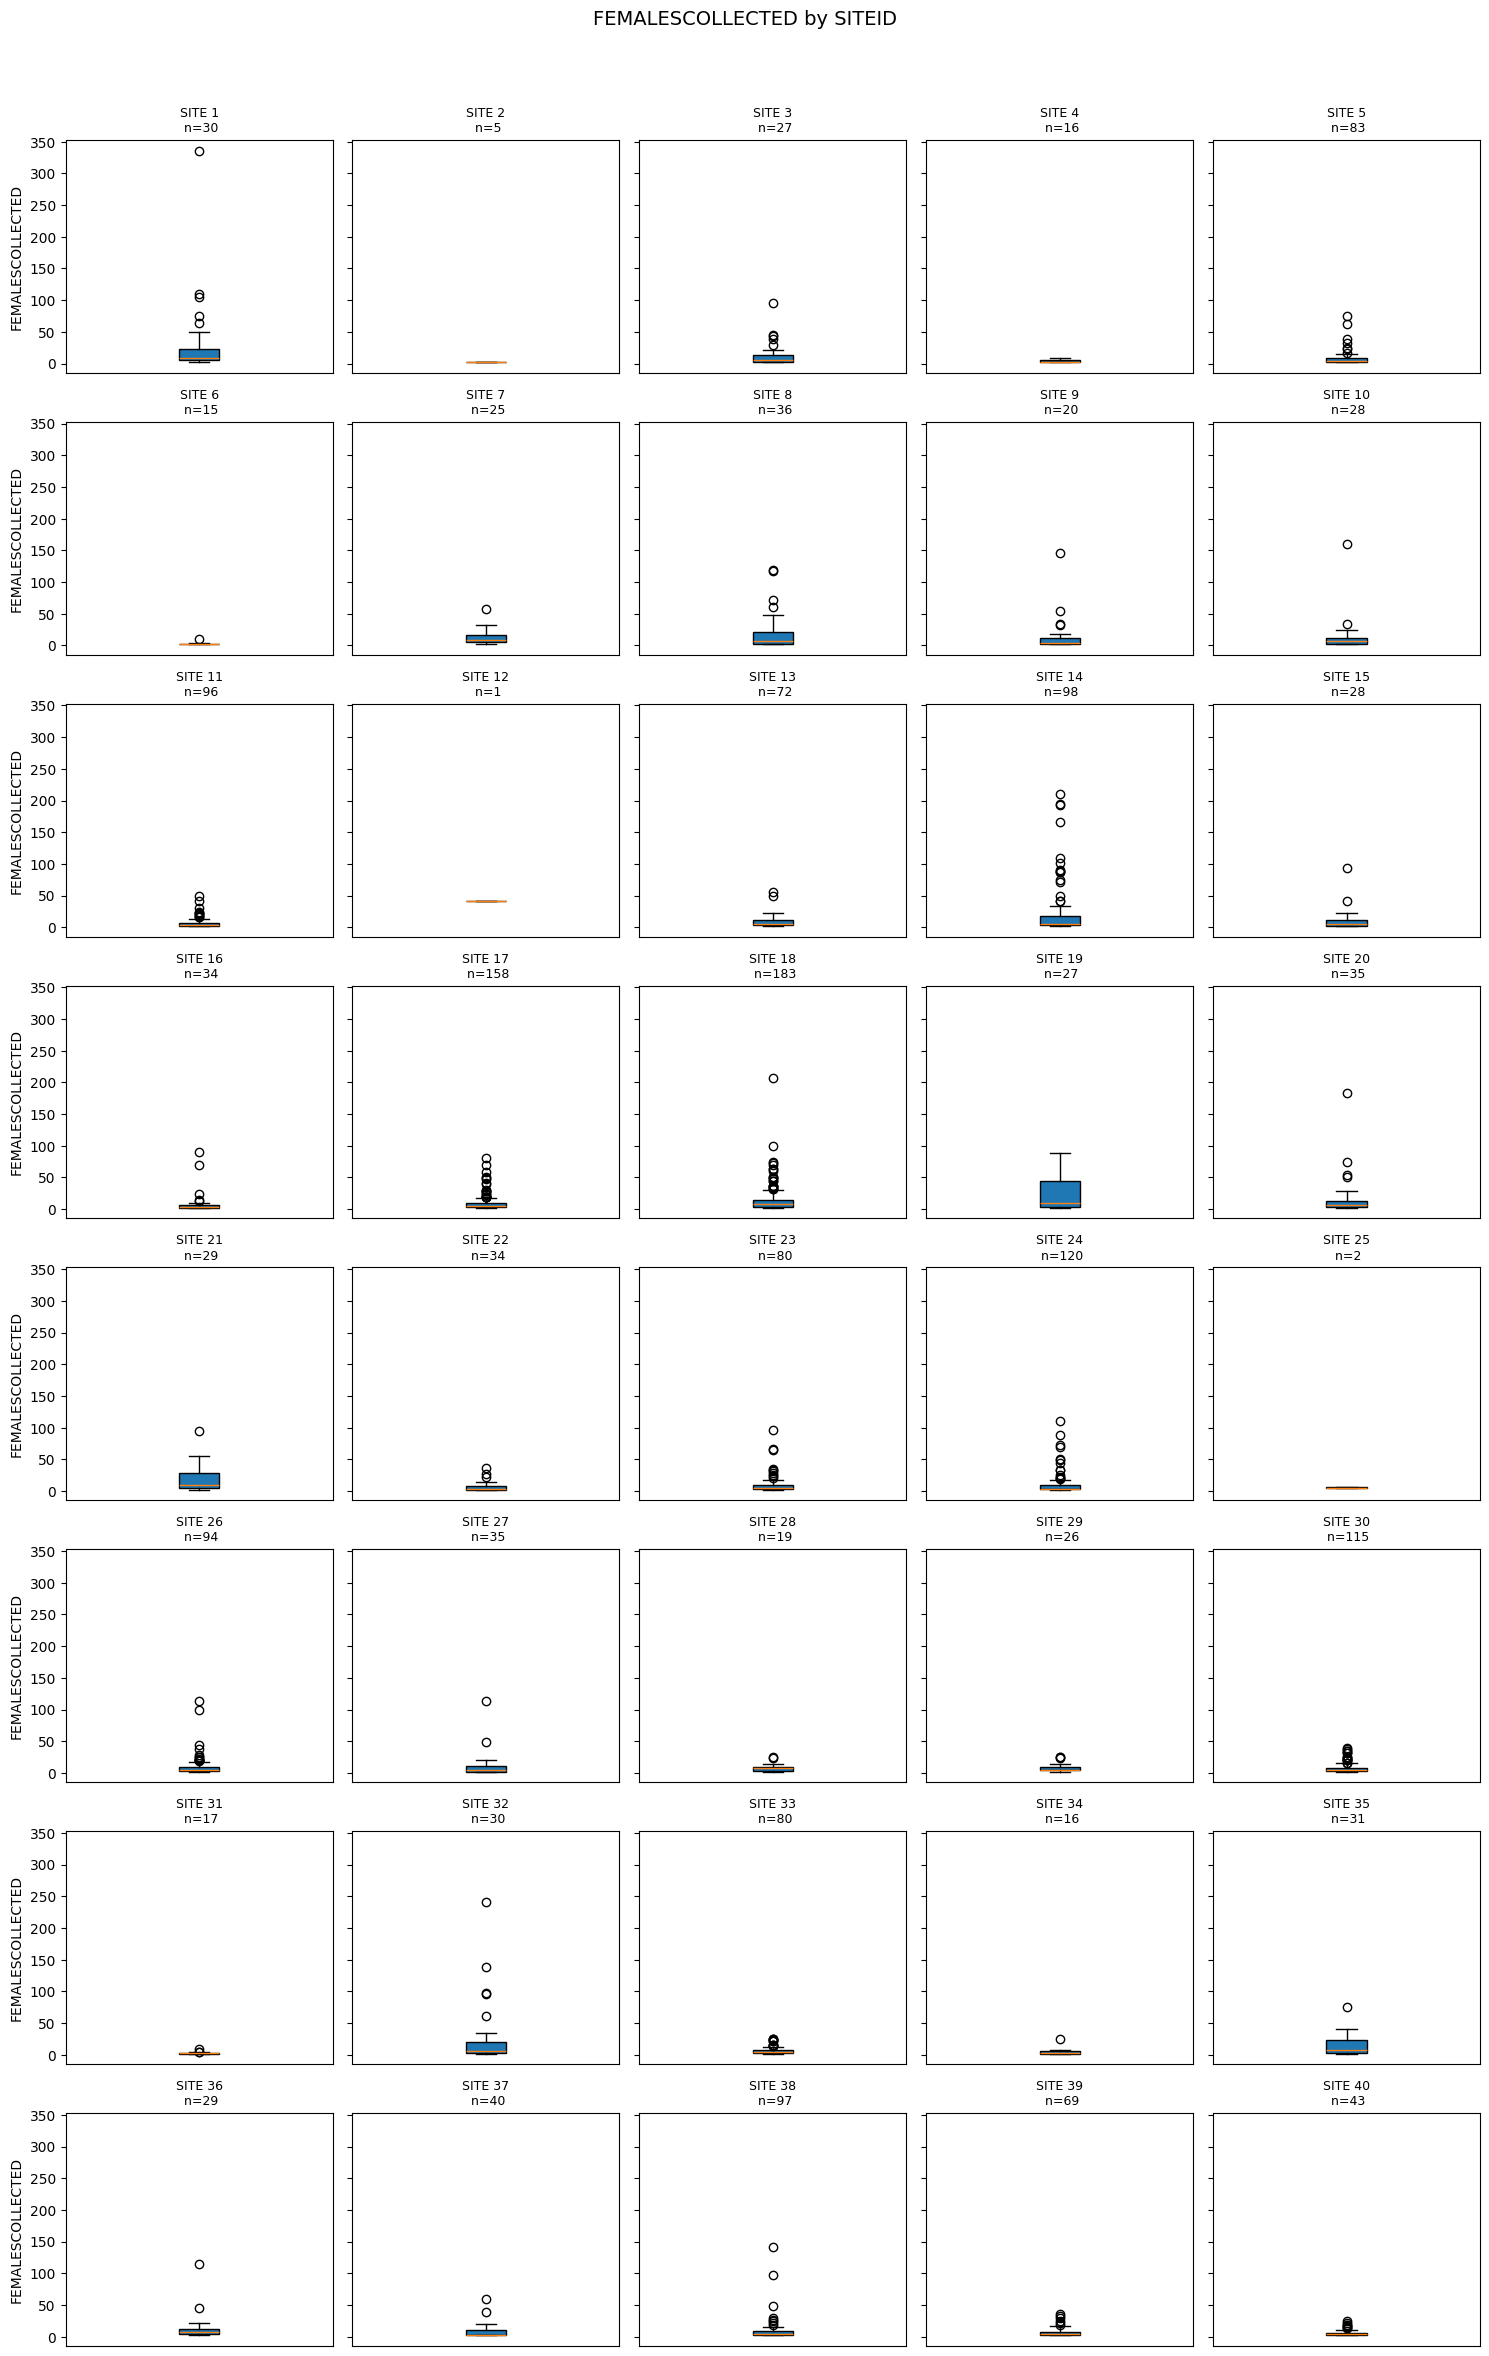

In [34]:
# Boxplot grid of FEMALESCOLLECTED by SITEID
site_ids = sorted(merged_df['SITEID'].unique())
n = len(site_ids)
n_cols = min(5, n)
n_rows = int(np.ceil(n / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3), sharey=True)
axes = axes.flatten()

for i, sid in enumerate(site_ids):
    ax = axes[i]
    vals = merged_df.loc[merged_df['SITEID'] == sid, 'FEMALESCOLLECTED'].dropna()
    if vals.empty:
        ax.set_visible(False)
        continue
    ax.boxplot(vals, patch_artist=True, boxprops=dict(facecolor='C0', edgecolor='k'))
    ax.set_title(f"SITE {sid}\n n={len(vals)}", fontsize=9)
    ax.set_xticks([])
    if i % n_cols == 0:
        ax.set_ylabel("FEMALESCOLLECTED")

fig.suptitle("FEMALESCOLLECTED by SITEID", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

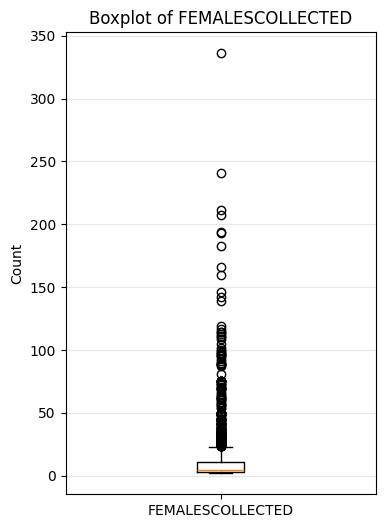

In [36]:
# boxplot of FEMALESCOLLECTED
plt.figure(figsize=(4, 6))
plt.boxplot(merged_df['FEMALESCOLLECTED'], vert=True, patch_artist=False, showfliers=True)
plt.xticks([1], ['FEMALESCOLLECTED'])
plt.ylabel('Count')
plt.title('Boxplot of FEMALESCOLLECTED')
plt.grid(axis='y', alpha=0.3)
plt.show()


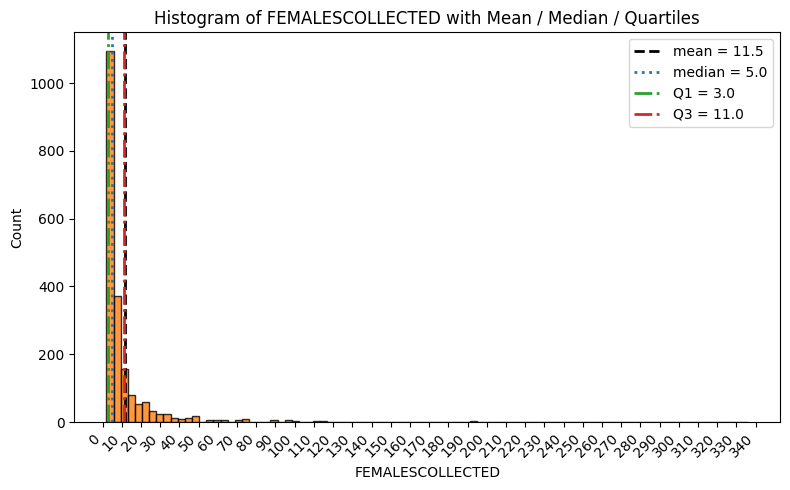

In [61]:
# Histogram of FEMALESCOLLECTED with mean, median and quartiles
data = merged_df['FEMALESCOLLECTED'].dropna()

mean = data.mean()
median = data.median()
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)

plt.figure(figsize=(8, 5))
plt.hist(data, bins=90, color='C1', edgecolor='k', alpha=0.8)
plt.axvline(mean, color='k', linestyle='--', linewidth=2, label=f"mean = {mean:.1f}")
plt.axvline(median, color='C0', linestyle=':', linewidth=2, label=f"median = {median:.1f}")
plt.axvline(q1, color='C2', linestyle='-.', linewidth=2, label=f"Q1 = {q1:.1f}")
plt.axvline(q3, color='C3', linestyle='-.', linewidth=2, label=f"Q3 = {q3:.1f}")

plt.xlabel('FEMALESCOLLECTED')
plt.xticks(np.arange(0, 350, step=10), rotation=45, ha='right')
plt.ylabel('Count')
plt.title('Histogram of FEMALESCOLLECTED with Mean / Median / Quartiles')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Calculate quartiles
q = (merged_df
    .groupby('SITEID')['FEMALESCOLLECTED']
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .rename(columns={0.25: 'Q1', 0.5: 'Median', 0.75: 'Q3'}))

# Add stats
q['IQR'] = q['Q3'] - q['Q1']
q['count'] = merged_df.groupby('SITEID')['FEMALESCOLLECTED'].count()

# Sum of FEMALESCOLLECTED
q['Total_Females'] = merged_df.groupby('SITEID')['FEMALESCOLLECTED'].sum()

# Sort descending
q = q.reset_index().sort_values(['Total_Females'], ascending=[False])

print(q.to_string(index=False))

 SITEID    Q1  Median    Q3   IQR  count  Total_Females
     18  4.00     8.0 15.00 11.00    183           2663
     14  3.00     6.0 17.50 14.50     98           2250
     17  3.00     5.0  9.00  6.00    158           1473
     24  2.75     4.0  9.00  6.25    120           1214
      1  5.25     9.0 23.75 18.50     30            976
     26  3.00     5.0  9.00  6.00     94            928
     38  3.00     5.0  9.00  6.00     97            905
     30  3.00     4.0  8.00  5.00    115            890
     32  3.00     6.5 19.50 16.50     30            843
     23  3.00     5.0  9.25  6.25     80            822
      8  3.00     7.5 21.50 18.50     36            729
     11  2.00     4.0  7.25  5.25     96            676
      5  3.00     4.0  8.00  5.00     83            649
     19  4.00     9.0 44.00 40.00     27            640
     13  3.00     5.0 11.00  8.00     72            606
     20  3.00     6.0 13.50 10.50     35            599
     21  5.00    10.0 28.00 23.00     29        

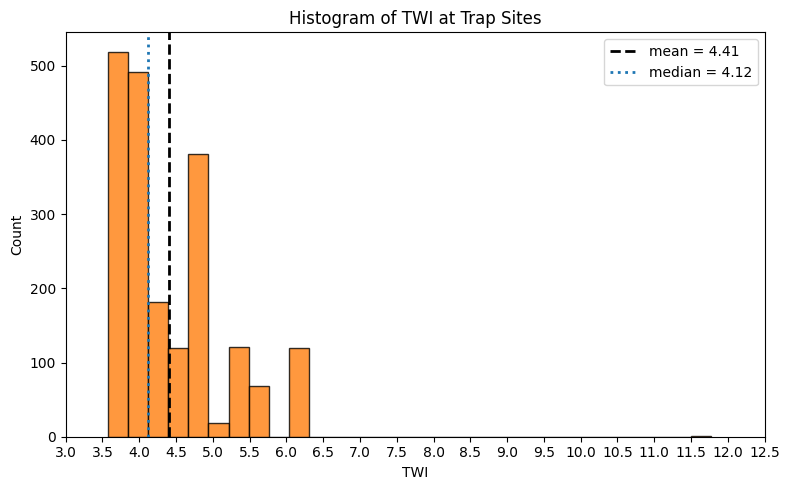

In [35]:
# Histogram of TWI from merged_df
twi = merged_df['TWI'].dropna()
mu = twi.mean()
med = twi.median()
plt.figure(figsize=(8, 5))
plt.hist(twi, bins=30, color='C1', edgecolor='k', alpha=0.8)
plt.axvline(mu, color='k', linestyle='--', linewidth=2, label=f"mean = {mu:.2f}")
plt.axvline(med, color='C0', linestyle=':', linewidth=2, label=f"median = {med:.2f}")
plt.xticks(np.arange(3, 13, step=.5))
plt.xlabel('TWI')
plt.ylabel('Count')
plt.title('Histogram of TWI at Trap Sites')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Engineering 1

### Add d/w/m

In [38]:
merged_df['day_of_year'] = merged_df['TRAPCOLLECT'].dt.dayofyear
merged_df['week'] = merged_df['TRAPCOLLECT'].dt.isocalendar().week.astype(int)
merged_df['month'] = merged_df['TRAPCOLLECT'].dt.month

### Abundance Labeling

#### Dropping sites with fewer than 10 observations
Sites: 12=1 observation, 2=5 observations, 25=2 observations

In [39]:
MIN_OBS = 10
valid_sites = merged_df.groupby('SITEID').filter(lambda x: len(x) >= MIN_OBS)
print(f"Kept {valid_sites['SITEID'].nunique()} sites, {len(valid_sites)} rows")

q33 = valid_sites['FEMALESCOLLECTED'].quantile(0.33)
q66 = valid_sites['FEMALESCOLLECTED'].quantile(0.66)

print(f"Low:  <= {q33:.1f} females")
print(f"Med:  <= {q66:.1f} females")
print(f"High: >  {q66:.1f} females")

valid_sites = valid_sites.copy()
valid_sites['ABUNDANCE_CLASS'] = pd.cut(
    valid_sites['FEMALESCOLLECTED'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]
).astype(int)

print(valid_sites['ABUNDANCE_CLASS'].value_counts(normalize=True).round(2).sort_index())

Kept 37 sites, 2015 rows
Low:  <= 3.0 females
Med:  <= 8.0 females
High: >  8.0 females
ABUNDANCE_CLASS
0    0.36
1    0.33
2    0.31
Name: proportion, dtype: float64


#### Checking for class balance
- Appears to be surprisingly balanced across low med high abundance classes

In [40]:
print(valid_sites['ABUNDANCE_CLASS'].value_counts().sort_index())
print(valid_sites['ABUNDANCE_CLASS'].value_counts(normalize=True).round(2).sort_index())

ABUNDANCE_CLASS
0    718
1    675
2    622
Name: count, dtype: int64
ABUNDANCE_CLASS
0    0.36
1    0.33
2    0.31
Name: proportion, dtype: float64


In [41]:
# Check class distribution per site
site_balance = valid_sites.groupby('SITEID')['ABUNDANCE_CLASS'].value_counts(
    normalize=True).round(2).unstack().fillna(0)
print(site_balance)

# Flag any sites heavily skewed toward one class
skewed = site_balance[site_balance.max(axis=1) > 0.6]
print(f"\nSites with >60% in one class:\n{skewed}")

ABUNDANCE_CLASS     0     1     2
SITEID                           
1                0.17  0.33  0.50
3                0.33  0.33  0.33
4                0.56  0.44  0.00
5                0.37  0.40  0.23
6                0.80  0.13  0.07
7                0.16  0.32  0.52
8                0.28  0.25  0.47
9                0.40  0.30  0.30
10               0.36  0.29  0.36
11               0.43  0.34  0.23
13               0.32  0.38  0.31
14               0.32  0.32  0.37
15               0.36  0.29  0.36
16               0.59  0.24  0.18
17               0.37  0.35  0.27
18               0.24  0.28  0.48
19               0.22  0.26  0.52
20               0.31  0.26  0.43
21               0.10  0.31  0.59
22               0.35  0.44  0.21
23               0.32  0.41  0.26
24               0.42  0.30  0.28
26               0.37  0.36  0.27
27               0.40  0.29  0.31
28               0.26  0.42  0.32
29               0.19  0.46  0.35
30               0.39  0.37  0.24
31            

### Feature Selection

In [ ]:
feature_cols = [
    # Spatial
    'LATITUDE', 'LONGITUDE', 'TWI',

    # Current weather
    'TAVG', 'TMAX', 'TMIN', 'PRCP',

    # Temperature lags
    'TAVG_lag7d', 'TAVG_lag14d', 'TAVG_lag21d',

    # Precipitation lags
    'PRCP_lag7d', 'PRCP_lag14d', 'PRCP_lag21d',

    # Rolling averages
    'TAVG_roll7', 'TAVG_roll14', 'PRCP_roll7',

    # Seasonality
    'day_of_year', 'week', 'month',

    # Time of collection
    'COLLECTTIMEOFDAY',

    # Target
    'ABUNDANCE_CLASS'
]

features_df = valid_sites[feature_cols].copy()

# One-hot encode collection time
features_df = pd.get_dummies(features_df, columns=['COLLECTTIMEOFDAY'], drop_first=True)

X = features_df.drop(columns='ABUNDANCE_CLASS')
y = features_df['ABUNDANCE_CLASS']

print(f"Features: {X.shape[1]}")
print(f"Samples:  {X.shape[0]}")
print(X.dtypes)

Features: 20
Samples:  2015
LATITUDE                    float64
LONGITUDE                   float64
TWI                         float64
TAVG                        float64
TMAX                        float64
TMIN                        float64
PRCP                        float64
TAVG_lag7d                  float64
TAVG_lag14d                 float64
TAVG_lag21d                 float64
PRCP_lag7d                  float64
PRCP_lag14d                 float64
PRCP_lag21d                 float64
TAVG_roll7                  float64
TAVG_roll14                 float64
PRCP_roll7                  float64
day_of_year                   int32
week                          int64
month                         int32
COLLECTTIMEOFDAY_Morning       bool
dtype: object


## XGB l/m/h

- Modest baseline - F1=.409 is better than random (.33)
- Fold 4 needed 101 trees; maybe a complex site

In [ ]:
gkf = GroupKFold(n_splits=5)
groups = valid_sites.loc[X.index, 'SITEID']

fold_scores  = []
best_n_trees = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        n_estimators=500,       # high ceiling — early stopping will cut this
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        random_state=42,
        eval_metric='mlogloss',
        #use_label_encoder=False,
        early_stopping_rounds=20  # stop if no improvement for 20 rounds
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_pred = model.predict(X_test)
    score  = f1_score(y_test, y_pred, average='macro')
    fold_scores.append(score)
    best_n_trees.append(model.best_iteration)

    print(f"Fold {fold+1} — macro F1: {score:.3f}, best iteration: {model.best_iteration}")

print(f"\nMean macro F1: {np.mean(fold_scores):.3f}")
print(f"Std:           {np.std(fold_scores):.3f}")
print(f"Avg best trees: {np.mean(best_n_trees):.0f}")


/Users/justinzwack/Mosquito_Predictor/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [21:57:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/justinzwack/Mosquito_Predictor/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [21:57:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Fold 1 — macro F1: 0.384, best iteration: 24
Fold 2 — macro F1: 0.384, best iteration: 27


/Users/justinzwack/Mosquito_Predictor/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [21:57:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
/Users/justinzwack/Mosquito_Predictor/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [21:57:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Fold 3 — macro F1: 0.419, best iteration: 29
Fold 4 — macro F1: 0.440, best iteration: 101


/Users/justinzwack/Mosquito_Predictor/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [21:57:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


Fold 5 — macro F1: 0.418, best iteration: 78

Mean macro F1: 0.409
Std:           0.022
Avg best trees: 52


### XGB l/m/h Performance

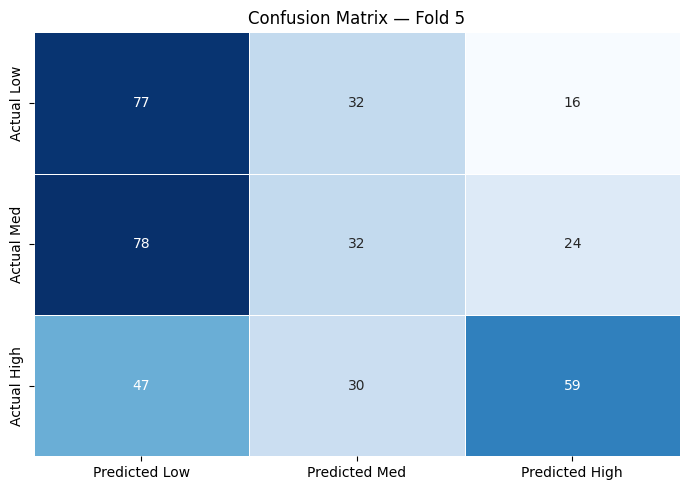

              precision    recall  f1-score   support

         Low       0.38      0.62      0.47       125
         Med       0.34      0.24      0.28       134
        High       0.60      0.43      0.50       136

    accuracy                           0.43       395
   macro avg       0.44      0.43      0.42       395
weighted avg       0.44      0.43      0.42       395



In [48]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['Actual Low', 'Actual Med', 'Actual High'],
    columns=['Predicted Low', 'Predicted Med', 'Predicted High']
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    cbar=False
)
plt.title('Confusion Matrix — Fold 5')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Low', 'Med', 'High']))

### Explore Alternative Classes

In [49]:
# Min and max FEMALESCOLLECTED per ABUNDANCE_CLASS
minmax = valid_sites.groupby('ABUNDANCE_CLASS')['FEMALESCOLLECTED'].agg(['min', 'max'])
print(minmax)

                 min  max
ABUNDANCE_CLASS          
0                  2    3
1                  4    8
2                  9  336


In [52]:
Q1  = valid_sites['FEMALESCOLLECTED'].quantile(0.25)
Q3  = valid_sites['FEMALESCOLLECTED'].quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + 1.5 * IQR
print(f"Outlier threshold: {upper_fence:.1f} females")

valid_sites['HIGH_ABUNDANCE'] = (valid_sites['FEMALESCOLLECTED'] > upper_fence).astype(int)
print(valid_sites['HIGH_ABUNDANCE'].value_counts())
print(valid_sites['HIGH_ABUNDANCE'].value_counts(normalize=True).round(2))

Outlier threshold: 23.0 females
HIGH_ABUNDANCE
0    1798
1     217
Name: count, dtype: int64
HIGH_ABUNDANCE
0    0.89
1    0.11
Name: proportion, dtype: float64


In [53]:
for pct in [0.70, 0.75, 0.80, 0.85]:
    threshold = valid_sites['FEMALESCOLLECTED'].quantile(pct)
    n_high    = (valid_sites['FEMALESCOLLECTED'] > threshold).sum()
    print(f"Top {100-pct*100:.0f}% — threshold: {threshold:.1f}, High: {n_high} ({1-pct:.0%})")

Top 30% — threshold: 9.0, High: 556 (30%)
Top 25% — threshold: 11.0, High: 474 (25%)
Top 20% — threshold: 13.0, High: 398 (20%)
Top 15% — threshold: 18.0, High: 294 (15%)


## XGB IQR-Threshold Class test

In [85]:
def run_xgb_threshold(valid_sites, feature_cols, threshold_value, threshold_name):
    """Run XGBoost CV for a given HIGH_ABUNDANCE threshold and return scores."""
    df = valid_sites.copy()
    df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
    df['HIGH_ABUNDANCE'] = (df['FEMALESCOLLECTED'] >= threshold_value).astype(int)
    
    n_low   = (df['HIGH_ABUNDANCE'] == 0).sum()
    n_high  = (df['HIGH_ABUNDANCE'] == 1).sum()
    scale   = n_low / n_high
    
    print(f"\n{'='*50}")
    print(f"Threshold: {threshold_name} (>= {threshold_value} females)")
    print(f"High: {n_high} ({n_high/len(df):.0%})  Low: {n_low} ({n_low/len(df):.0%})")
    print(f"scale_pos_weight: {scale:.1f}")
    
    X = df[feature_cols].copy()
    y = df['HIGH_ABUNDANCE']
    groups = df['SITEID']
    
    bool_cols = X.select_dtypes(include='bool').columns
    X[bool_cols] = X[bool_cols].astype(int)
    
    gkf = GroupKFold(n_splits=5)
    
    fold_f1      = []
    fold_roc_auc = []
    best_trees   = []
    
    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = XGBClassifier(
            scale_pos_weight=scale,
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            random_state=42,
            eval_metric='logloss',
            early_stopping_rounds=20,
            enable_categorical=True
        )
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )
        
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        
        f1      = f1_score(y_test, y_pred, average='macro')
        roc_auc = roc_auc_score(y_test, y_proba)
        
        fold_f1.append(f1)
        fold_roc_auc.append(roc_auc)
        best_trees.append(model.best_iteration)
        
        print(f"  Fold {fold+1} — macro F1: {f1:.3f}  ROC-AUC: {roc_auc:.3f}  trees: {model.best_iteration}")
    
    print(f"\n  Mean macro F1: {np.mean(fold_f1):.3f} (+/- {np.std(fold_f1):.3f})")
    print(f"  Mean ROC-AUC:  {np.mean(fold_roc_auc):.3f} (+/- {np.std(fold_roc_auc):.3f})")
    print(f"  Avg best trees: {np.mean(best_trees):.0f}")
    
    return {
        'threshold_name':  threshold_name,
        'threshold_value': threshold_value,
        'n_high':          n_high,
        'pct_high':        n_high / len(df),
        'mean_f1':         np.mean(fold_f1),
        'mean_roc_auc':    np.mean(fold_roc_auc),
        'std_f1':          np.std(fold_f1),
        'std_roc_auc':     np.std(fold_roc_auc)
    }

# --- Log transformed feature cols ---
log_feat_cols = [
    'LATITUDE', 'LONGITUDE', 'TWI_log',
    'TAVG', 'TMAX', 'TMIN', 'PRCP_log',
    'TAVG_lag7d', 'TAVG_lag14d', 'TAVG_lag21d',
    'PRCP_lag7d_log', 'PRCP_lag14d_log', 'PRCP_lag21d_log',
    'TAVG_roll7', 'TAVG_roll14', 'PRCP_roll7_log',
    'day_of_year', 'week', 'month',
    'COLLECTTIMEOFDAY'
]

# --- Compute IQR threshold ---
Q1  = valid_sites['FEMALESCOLLECTED'].quantile(0.25)
Q3  = valid_sites['FEMALESCOLLECTED'].quantile(0.75)
IQR = Q3 - Q1
iqr_threshold = int(Q3 + 1.5 * IQR)

# --- Run both ---
results = []
results.append(run_xgb_threshold(valid_sites, log_feat_cols, iqr_threshold, 'IQR 1.5x log'))
results.append(run_xgb_threshold(valid_sites, log_feat_cols, 11, 'Top 25% log'))

# --- Summary ---
results_df = pd.DataFrame(results)[[
    'threshold_name', 'threshold_value', 'n_high',
    'pct_high', 'mean_f1', 'mean_roc_auc'
]]
results_df['pct_high']     = results_df['pct_high'].round(2)
results_df['mean_f1']      = results_df['mean_f1'].round(3)
results_df['mean_roc_auc'] = results_df['mean_roc_auc'].round(3)
print(results_df.to_string(index=False))


Threshold: IQR 1.5x log (>= 23 females)
High: 228 (11%)  Low: 1787 (89%)
scale_pos_weight: 7.8
  Fold 1 — macro F1: 0.624  ROC-AUC: 0.692  trees: 100
  Fold 2 — macro F1: 0.594  ROC-AUC: 0.795  trees: 76
  Fold 3 — macro F1: 0.598  ROC-AUC: 0.766  trees: 99
  Fold 4 — macro F1: 0.588  ROC-AUC: 0.832  trees: 176
  Fold 5 — macro F1: 0.723  ROC-AUC: 0.846  trees: 74

  Mean macro F1: 0.625 (+/- 0.050)
  Mean ROC-AUC:  0.786 (+/- 0.055)
  Avg best trees: 105

Threshold: Top 25% log (>= 11 females)
High: 508 (25%)  Low: 1507 (75%)
scale_pos_weight: 3.0
  Fold 1 — macro F1: 0.593  ROC-AUC: 0.638  trees: 36
  Fold 2 — macro F1: 0.612  ROC-AUC: 0.720  trees: 129
  Fold 3 — macro F1: 0.593  ROC-AUC: 0.664  trees: 72
  Fold 4 — macro F1: 0.607  ROC-AUC: 0.723  trees: 117
  Fold 5 — macro F1: 0.669  ROC-AUC: 0.744  trees: 69

  Mean macro F1: 0.615 (+/- 0.028)
  Mean ROC-AUC:  0.698 (+/- 0.040)
  Avg best trees: 85
threshold_name  threshold_value  n_high  pct_high  mean_f1  mean_roc_auc
  IQR 1

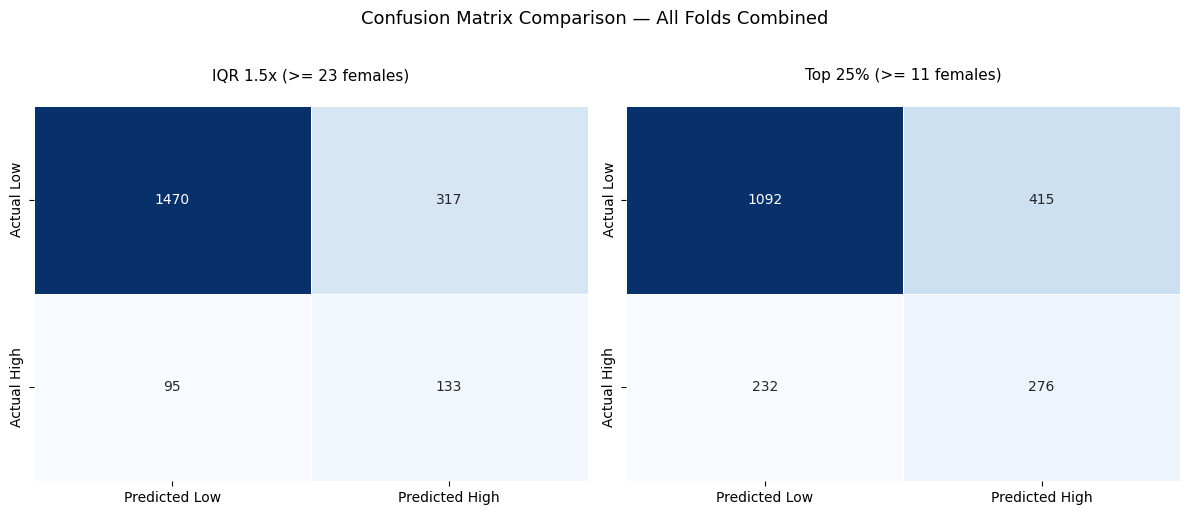

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

thresholds = [
    (23,  'IQR 1.5x (>= 23 females)'),
    (11,  'Top 25% (>= 11 females)')
]

Q1  = valid_sites['FEMALESCOLLECTED'].quantile(0.25)
Q3  = valid_sites['FEMALESCOLLECTED'].quantile(0.75)
IQR = Q3 - Q1

gkf    = GroupKFold(n_splits=5)

for ax, (threshold_value, threshold_name) in zip(axes, thresholds):
    df = valid_sites.copy()
    df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
    df['HIGH_ABUNDANCE']   = (df['FEMALESCOLLECTED'] >= threshold_value).astype(int)

    n_low  = (df['HIGH_ABUNDANCE'] == 0).sum()
    n_high = (df['HIGH_ABUNDANCE'] == 1).sum()
    scale  = n_low / n_high

    X      = df[feature_cols].copy()
    y      = df['HIGH_ABUNDANCE']
    groups = df['SITEID']

    # Collect all predictions across folds
    all_y_true = []
    all_y_pred = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = XGBClassifier(
            scale_pos_weight=scale,
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            random_state=42,
            eval_metric='logloss',
            early_stopping_rounds=20,
            enable_categorical=True
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        all_y_true.extend(y_test.tolist())
        all_y_pred.extend(model.predict(X_test).tolist())

    # Build confusion matrix from all folds combined
    cm = confusion_matrix(all_y_true, all_y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=['Actual Low', 'Actual High'],
        columns=['Predicted Low', 'Predicted High']
    )

    sns.heatmap(
        cm_df,
        annot=True,
        fmt='d',
        cmap='Blues',
        linewidths=0.5,
        cbar=False,
        ax=ax
    )
    ax.set_title(f'{threshold_name}\n', fontsize=11)

plt.suptitle('Confusion Matrix Comparison — All Folds Combined', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Log Xforms

Checking for skew in features to transform

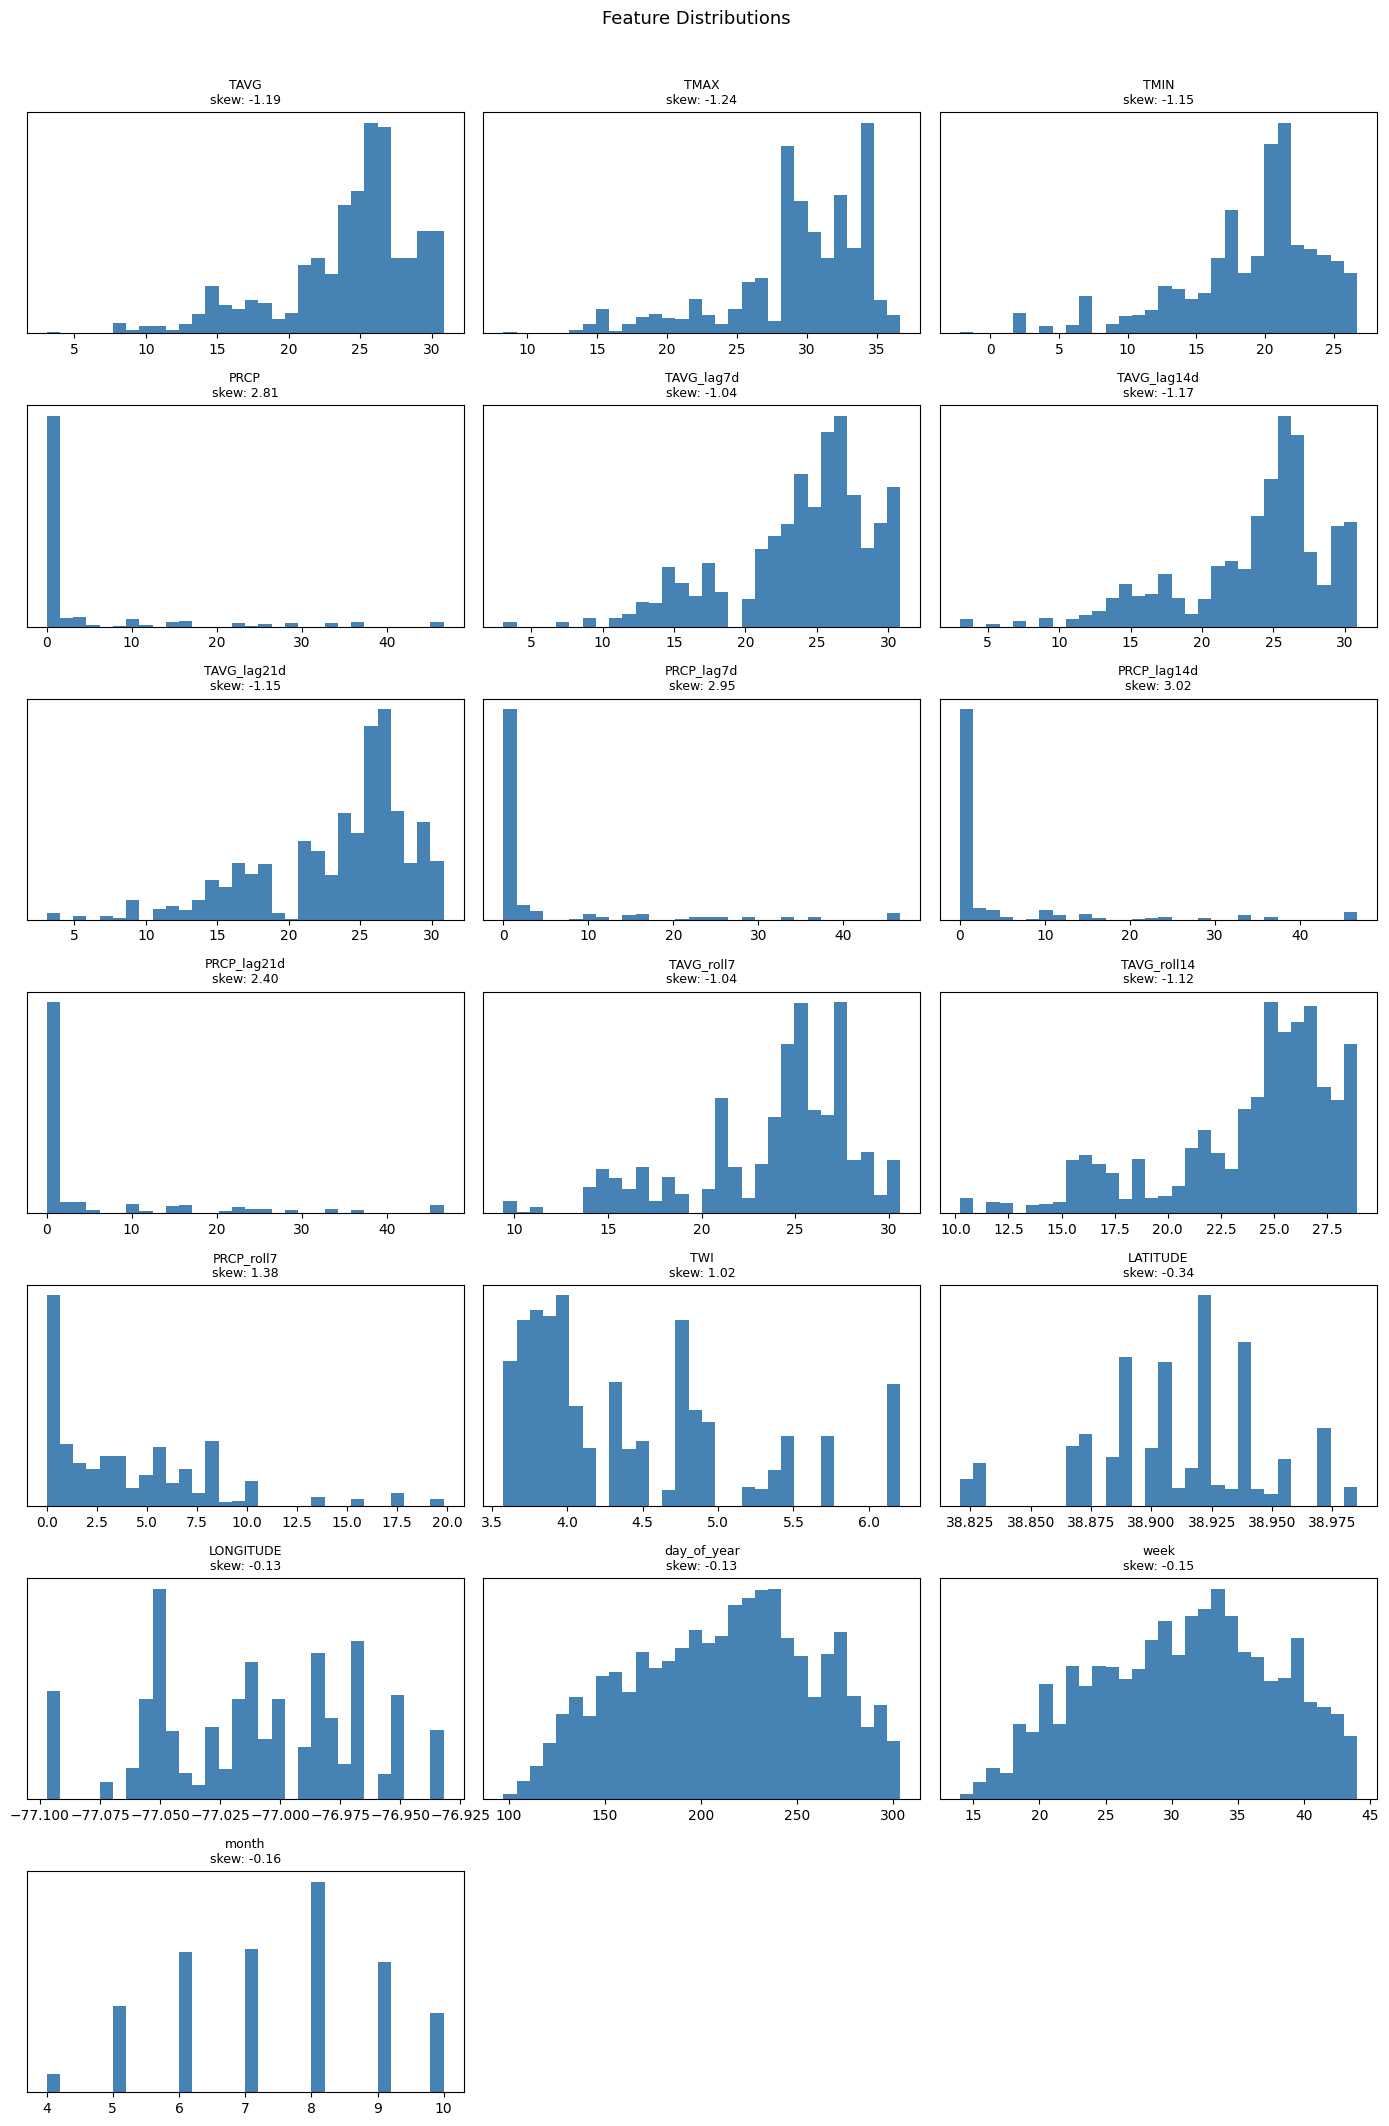

PRCP_lag14d    3.02
PRCP_lag7d     2.95
PRCP           2.81
PRCP_lag21d    2.40
PRCP_roll7     1.38
TWI            1.02
day_of_year   -0.13
LONGITUDE     -0.13
week          -0.15
month         -0.16
LATITUDE      -0.34
TAVG_roll7    -1.04
TAVG_lag7d    -1.04
TAVG_roll14   -1.12
TAVG_lag21d   -1.15
TMIN          -1.15
TAVG_lag14d   -1.17
TAVG          -1.19
TMAX          -1.24
dtype: float64


In [71]:
numeric_cols = [
    'TAVG', 'TMAX', 'TMIN', 'PRCP',
    'TAVG_lag7d', 'TAVG_lag14d', 'TAVG_lag21d',
    'PRCP_lag7d', 'PRCP_lag14d', 'PRCP_lag21d',
    'TAVG_roll7', 'TAVG_roll14', 'PRCP_roll7',
    'TWI', 'LATITUDE', 'LONGITUDE',
    'day_of_year', 'week', 'month'
]

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))  # automatically calculates rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    skew = valid_sites[col].skew()
    axes[i].hist(valid_sites[col], bins=30, color='steelblue', edgecolor='none')
    axes[i].set_title(f'{col}\nskew: {skew:.2f}', fontsize=9)
    axes[i].set_yticks([])

# Hide any unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

skew_df = valid_sites[numeric_cols].skew().round(2).sort_values(ascending=False)
print(skew_df)

transforming the following features. Results did not improve after re-running with log transformations. Not surprising with XGB. Will attempt to add some additional features.

In [74]:
# Log transform precipitation columns
prcp_cols = ['PRCP', 'PRCP_lag7d', 'PRCP_lag14d', 'PRCP_lag21d', 'PRCP_roll7']
for col in prcp_cols:
    valid_sites[f'{col}_log'] = np.log1p(valid_sites[col])

# TWI log transform
valid_sites['TWI_log'] = np.log1p(valid_sites['TWI'])

# Verify distributions improved
log_cols = [f'{col}_log' for col in prcp_cols] + ['TWI_log']
skew_after = valid_sites[log_cols].skew().round(2).sort_values(ascending=False)
print("Skewness after log transform:")
print(skew_after)

Skewness after log transform:
PRCP_lag7d_log     1.72
PRCP_log           1.66
PRCP_lag14d_log    1.65
PRCP_lag21d_log    1.31
TWI_log            0.82
PRCP_roll7_log    -0.07
dtype: float64


### New Features

In [90]:
# Sort by date first — required for cumulative calculations
valid_sites = valid_sites.sort_values('DATE').reset_index(drop=True)

BASE_TEMP = 10  # degrees C — standard for Culex mosquitoes

# --- Degree days ---
valid_sites['degree_days']     = (valid_sites['TAVG'] - BASE_TEMP).clip(lower=0)
valid_sites['cum_degree_days'] = valid_sites.groupby(
    valid_sites['DATE'].dt.year)['degree_days'].cumsum()

# --- Wet day sequences ---
valid_sites['wet_days_14d']    = (
    valid_sites['PRCP'].gt(0)
    .rolling(14, min_periods=1)
    .sum()
    .astype(int)
)
valid_sites['days_since_rain'] = (
    valid_sites['PRCP'].eq(0)
    .groupby(valid_sites['DATE'].dt.year)
    .cumsum()
    .astype(int)
)

# --- Temperature x precipitation interactions ---
valid_sites['temp_x_precip_7d']  = valid_sites['TAVG_roll7']  * valid_sites['PRCP_roll7_log']
valid_sites['temp_x_precip_14d'] = valid_sites['TAVG_roll14'] * valid_sites['PRCP_roll7_log']

# --- Temperature range ---
valid_sites['temp_range']        = valid_sites['TMAX'] - valid_sites['TMIN']
valid_sites['temp_range_roll7']  = valid_sites['temp_range'].rolling(7, min_periods=1).mean()

# --- Verify no nulls ---
new_cols = [
    'cum_degree_days', 'wet_days_14d', 'days_since_rain',
    'temp_x_precip_7d', 'temp_x_precip_14d',
    'temp_range', 'temp_range_roll7'
]
print("Null check:")
print(valid_sites[new_cols].isnull().sum())
print(f"\nSample values:")
print(valid_sites[new_cols].describe().round(2))

Null check:
cum_degree_days      0
wet_days_14d         0
days_since_rain      0
temp_x_precip_7d     0
temp_x_precip_14d    0
temp_range           0
temp_range_roll7     0
dtype: int64

Sample values:
       cum_degree_days  wet_days_14d  days_since_rain  temp_x_precip_7d  \
count          2015.00       2015.00          2015.00           2015.00   
mean           5214.97          4.06           257.96             30.21   
std            3890.13          5.77           186.90             22.49   
min               0.00          0.00             1.00              0.00   
25%            1882.10          0.00           109.50              7.79   
50%            4664.90          0.00           208.00             31.81   
75%            7355.15         10.00           388.50             49.79   
max           13608.10         14.00           729.00             76.40   

       temp_x_precip_14d  temp_range  temp_range_roll7  
count            2015.00     2015.00           2015.00  
mean    

### Test New Features

In [93]:
log_feat_cols = [
    # Spatial
    'LATITUDE', 'LONGITUDE', 'TWI_log',
    # Current weather
    'TAVG', 'TMAX', 'TMIN', 'PRCP_log',
    # Temperature lags
    'TAVG_lag7d', 'TAVG_lag14d', 'TAVG_lag21d',
    # Precipitation lags
    'PRCP_lag7d_log', 'PRCP_lag14d_log', 'PRCP_lag21d_log',
    # Rolling averages
    'TAVG_roll7', 'TAVG_roll14', 'PRCP_roll7_log',
    # Engineered features
    'cum_degree_days', 'wet_days_14d', 'days_since_rain',
    'temp_x_precip_7d', 'temp_x_precip_14d',
    'temp_range', 'temp_range_roll7',
    # Seasonality
    'day_of_year', 'week', 'month',
    # Time of collection
    'COLLECTTIMEOFDAY'
]

results = []
results.append(run_xgb_threshold(valid_sites, log_feat_cols, iqr_threshold, 'IQR 1.5x engineered'))
results.append(run_xgb_threshold(valid_sites, log_feat_cols, 11, 'Top 25% engineered'))

results_df = pd.DataFrame(results)[[
    'threshold_name', 'threshold_value', 'n_high',
    'pct_high', 'mean_f1', 'mean_roc_auc'
]]
results_df['pct_high']     = results_df['pct_high'].round(2)
results_df['mean_f1']      = results_df['mean_f1'].round(3)
results_df['mean_roc_auc'] = results_df['mean_roc_auc'].round(3)
print(results_df.to_string(index=False))


Threshold: IQR 1.5x engineered (>= 23 females)
High: 228 (11%)  Low: 1787 (89%)
scale_pos_weight: 7.8
  Fold 1 — macro F1: 0.624  ROC-AUC: 0.680  trees: 124
  Fold 2 — macro F1: 0.617  ROC-AUC: 0.795  trees: 77
  Fold 3 — macro F1: 0.593  ROC-AUC: 0.745  trees: 209
  Fold 4 — macro F1: 0.650  ROC-AUC: 0.831  trees: 230
  Fold 5 — macro F1: 0.720  ROC-AUC: 0.834  trees: 131

  Mean macro F1: 0.641 (+/- 0.044)
  Mean ROC-AUC:  0.777 (+/- 0.058)
  Avg best trees: 154

Threshold: Top 25% engineered (>= 11 females)
High: 508 (25%)  Low: 1507 (75%)
scale_pos_weight: 3.0
  Fold 1 — macro F1: 0.620  ROC-AUC: 0.671  trees: 27
  Fold 2 — macro F1: 0.617  ROC-AUC: 0.723  trees: 138
  Fold 3 — macro F1: 0.633  ROC-AUC: 0.692  trees: 58
  Fold 4 — macro F1: 0.641  ROC-AUC: 0.731  trees: 49
  Fold 5 — macro F1: 0.696  ROC-AUC: 0.747  trees: 84

  Mean macro F1: 0.641 (+/- 0.029)
  Mean ROC-AUC:  0.713 (+/- 0.028)
  Avg best trees: 71
     threshold_name  threshold_value  n_high  pct_high  mean_f1  

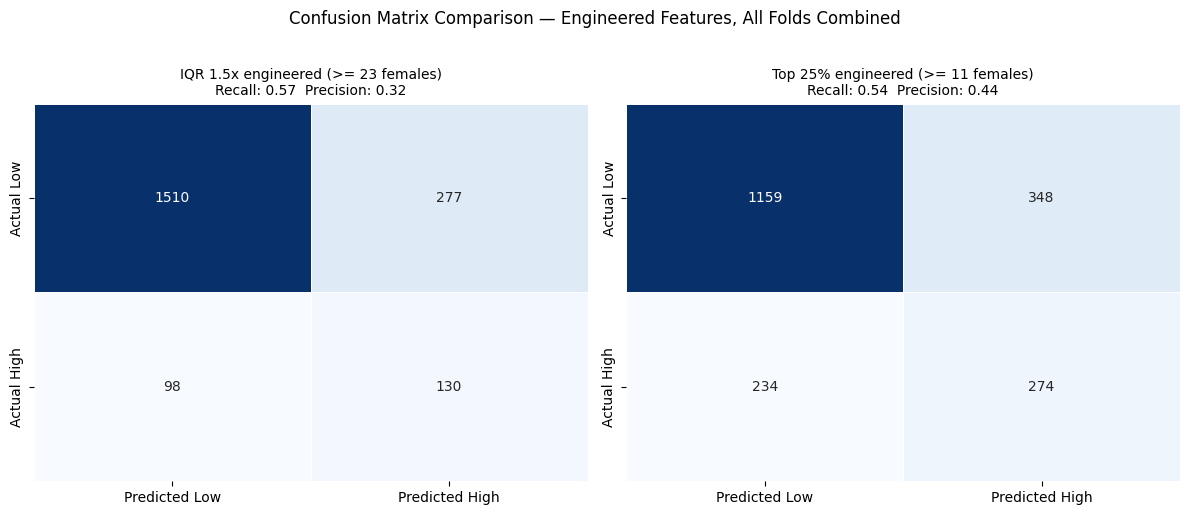

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

thresholds = [
    (23, 'IQR 1.5x engineered (>= 23 females)'),
    (11, 'Top 25% engineered (>= 11 females)')
]

for ax, (threshold_value, threshold_name) in zip(axes, thresholds):
    df = valid_sites.copy()
    df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
    df['HIGH_ABUNDANCE']   = (df['FEMALESCOLLECTED'] >= threshold_value).astype(int)

    n_low  = (df['HIGH_ABUNDANCE'] == 0).sum()
    n_high = (df['HIGH_ABUNDANCE'] == 1).sum()
    scale  = n_low / n_high

    X      = df[log_feat_cols].copy()
    y      = df['HIGH_ABUNDANCE']
    groups = df['SITEID']

    gkf = GroupKFold(n_splits=5)

    all_y_true = []
    all_y_pred = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = XGBClassifier(
            scale_pos_weight=scale,
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            random_state=42,
            eval_metric='logloss',
            early_stopping_rounds=20,
            enable_categorical=True
        )

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        all_y_true.extend(y_test.tolist())
        all_y_pred.extend(model.predict(X_test).tolist())

    # Compute metrics
    cm = confusion_matrix(all_y_true, all_y_pred)
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn)
    precision = tp / (tp + fp)

    cm_df = pd.DataFrame(
        cm,
        index=['Actual Low', 'Actual High'],
        columns=['Predicted Low', 'Predicted High']
    )

    sns.heatmap(
        cm_df,
        annot=True,
        fmt='d',
        cmap='Blues',
        linewidths=0.5,
        cbar=False,
        ax=ax
    )
    ax.set_title(
        f'{threshold_name}\n'
        f'Recall: {recall:.2f}  Precision: {precision:.2f}',
        fontsize=10
    )

plt.suptitle('Confusion Matrix Comparison — Engineered Features, All Folds Combined',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Feature Importance
- All features are contributing
- Day and week and contributing most significantly
- Days since rain is the best weather feature

Fold 1 done — best iteration: 124
Fold 2 done — best iteration: 77
Fold 3 done — best iteration: 209
Fold 4 done — best iteration: 230
Fold 5 done — best iteration: 131


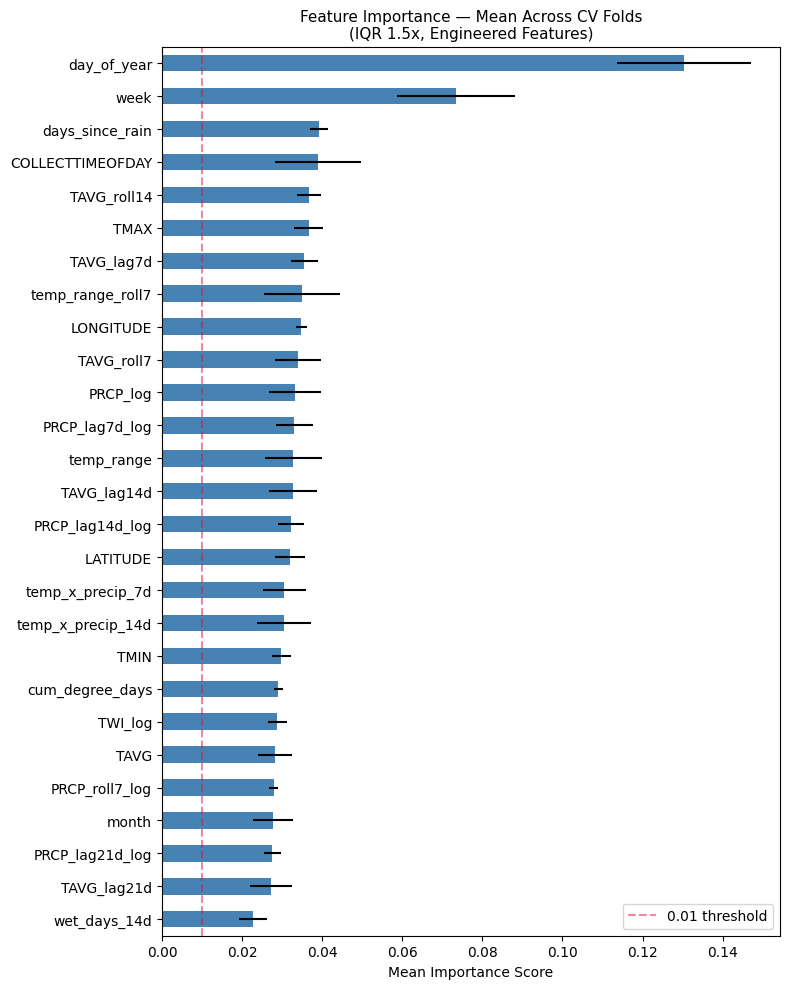


Mean feature importance ranked:
day_of_year          0.1302
week                 0.0734
days_since_rain      0.0392
COLLECTTIMEOFDAY     0.0389
TAVG_roll14          0.0367
TMAX                 0.0366
TAVG_lag7d           0.0356
temp_range_roll7     0.0349
LONGITUDE            0.0348
TAVG_roll7           0.0339
PRCP_log             0.0332
PRCP_lag7d_log       0.0330
temp_range           0.0328
TAVG_lag14d          0.0326
PRCP_lag14d_log      0.0322
LATITUDE             0.0321
temp_x_precip_7d     0.0305
temp_x_precip_14d    0.0304
TMIN                 0.0298
cum_degree_days      0.0290
TWI_log              0.0288
TAVG                 0.0282
PRCP_roll7_log       0.0279
month                0.0277
PRCP_lag21d_log      0.0276
TAVG_lag21d          0.0271
wet_days_14d         0.0227
dtype: float32

Features below 0.01 importance (candidates to drop):
Series([], dtype: float32)


In [96]:
df = valid_sites.copy()
df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
df['HIGH_ABUNDANCE']   = (df['FEMALESCOLLECTED'] >= 23).astype(int)

n_low  = (df['HIGH_ABUNDANCE'] == 0).sum()
n_high = (df['HIGH_ABUNDANCE'] == 1).sum()
scale  = n_low / n_high

X      = df[log_feat_cols].copy()
y      = df['HIGH_ABUNDANCE']
groups = df['SITEID']

gkf = GroupKFold(n_splits=5)

# Collect importance from each fold
fold_importances = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        scale_pos_weight=scale,
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        random_state=42,
        eval_metric='logloss',
        early_stopping_rounds=20,
        enable_categorical=True
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    fold_importances.append(
        pd.Series(model.feature_importances_, index=log_feat_cols)
    )
    print(f"Fold {fold+1} done — best iteration: {model.best_iteration}")

# Average importance across folds
importance_df = pd.DataFrame(fold_importances)
mean_importance = importance_df.mean().sort_values(ascending=True)
std_importance  = importance_df.std()

# Plot with error bars showing variance across folds
fig, ax = plt.subplots(figsize=(8, 10))
colors = ['crimson' if v < 0.01 else 'steelblue' for v in mean_importance.values]

mean_importance.plot(kind='barh', ax=ax, color=colors, xerr=std_importance[mean_importance.index])
ax.axvline(x=0.01, color='crimson', linestyle='--', alpha=0.5, label='0.01 threshold')
ax.set_title('Feature Importance — Mean Across CV Folds\n(IQR 1.5x, Engineered Features)', fontsize=11)
ax.set_xlabel('Mean Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

print("\nMean feature importance ranked:")
print(mean_importance.sort_values(ascending=False).round(4))

print(f"\nFeatures below 0.01 importance (candidates to drop):")
print(mean_importance[mean_importance < 0.01].sort_values().round(4))

### Classification Thresholds
- Diminishing returns after threshold of about .3

In [99]:
df = valid_sites.copy()
df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
df['HIGH_ABUNDANCE']   = (df['FEMALESCOLLECTED'] >= 23).astype(int)

n_low  = (df['HIGH_ABUNDANCE'] == 0).sum()
n_high = (df['HIGH_ABUNDANCE'] == 1).sum()
scale  = n_low / n_high

X      = df[log_feat_cols].copy()
y      = df['HIGH_ABUNDANCE']
groups = df['SITEID']

gkf = GroupKFold(n_splits=5)

# Test multiple thresholds
prob_thresholds = [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]
threshold_results = {t: {'recall': [], 'precision': [], 'f1': []} for t in prob_thresholds}

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        scale_pos_weight=scale,
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        random_state=42,
        eval_metric='logloss',
        early_stopping_rounds=20,
        enable_categorical=True
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_proba = model.predict_proba(X_test)[:, 1]

    for t in prob_thresholds:
        y_pred = (y_proba >= t).astype(int)
        threshold_results[t]['recall'].append(recall_score(y_test, y_pred))
        threshold_results[t]['precision'].append(precision_score(y_test, y_pred, zero_division=0))
        threshold_results[t]['f1'].append(f1_score(y_test, y_pred, average='macro'))

# Summary table
print(f"{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'Macro F1':<10}")
print("-" * 44)
for t in prob_thresholds:
    r = np.mean(threshold_results[t]['recall'])
    p = np.mean(threshold_results[t]['precision'])
    f = np.mean(threshold_results[t]['f1'])
    print(f"{t:<12.2f} {r:<10.3f} {p:<12.3f} {f:<10.3f}")

Threshold    Recall     Precision    Macro F1  
--------------------------------------------
0.50         0.573      0.315        0.641     
0.40         0.605      0.266        0.608     
0.35         0.662      0.251        0.593     
0.30         0.707      0.232        0.572     
0.25         0.774      0.220        0.551     
0.20         0.796      0.197        0.512     


dummy random baseline F1: 0.481

In [ ]:
dummy_strat = []
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    y_test  = y.iloc[test_idx]
    
    dummy = DummyClassifier(strategy='stratified', random_state=42)
    dummy.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred = dummy.predict(X.iloc[test_idx])
    
    dummy_strat.append(f1_score(y_test, y_pred, average='macro'))

print(f"Stratified random baseline macro F1: {np.mean(dummy_strat):.3f}")

Stratified random baseline macro F1: 0.481


### XGB Recall

In [129]:
def run_xgb_recall(valid_sites, feat_cols, threshold_value, threshold_name, 
                   prob_threshold=0.30, model_params=None):
    
    df = valid_sites.copy()
    df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
    df['HIGH_ABUNDANCE']   = (df['FEMALESCOLLECTED'] >= threshold_value).astype(int)

    n_low  = (df['HIGH_ABUNDANCE'] == 0).sum()
    n_high = (df['HIGH_ABUNDANCE'] == 1).sum()
    scale  = n_low / n_high

    # Use provided params or fall back to defaults
    if model_params is None:
        model_params = {
            'scale_pos_weight':      scale,
            'n_estimators':          500,
            'max_depth':             3,
            'learning_rate':         0.05,
            'subsample':             0.7,
            'colsample_bytree':      0.7,
            'min_child_weight':      10,
            'random_state':          42,
            'eval_metric':           'logloss',
            'early_stopping_rounds': 20,
            'enable_categorical':    True
        }

    print(f"\n{'='*50}")
    print(f"Threshold: {threshold_name} (>= {threshold_value} females)")
    print(f"Prob threshold: {prob_threshold}")
    print(f"High: {n_high} ({n_high/len(df):.0%})  Low: {n_low} ({n_low/len(df):.0%})")
    print(f"scale_pos_weight: {model_params.get('scale_pos_weight', scale):.1f}")

    X      = df[feat_cols].copy()
    y      = df['HIGH_ABUNDANCE']
    groups = df['SITEID']

    gkf            = GroupKFold(n_splits=5)
    fold_f1        = []
    fold_roc_auc   = []
    fold_recall    = []
    fold_precision = []
    best_trees     = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = XGBClassifier(**model_params)

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred  = (y_proba >= prob_threshold).astype(int)

        fold_f1.append(f1_score(y_test, y_pred, average='macro'))
        fold_roc_auc.append(roc_auc_score(y_test, y_proba))
        fold_recall.append(recall_score(y_test, y_pred))
        fold_precision.append(precision_score(y_test, y_pred, zero_division=0))
        best_trees.append(model.best_iteration)

        print(f"  Fold {fold+1} — Recall: {fold_recall[-1]:.3f}  Precision: {fold_precision[-1]:.3f}  "
              f"Macro F1: {fold_f1[-1]:.3f}  ROC-AUC: {fold_roc_auc[-1]:.3f}  trees: {model.best_iteration}")

    print(f"\n  Mean Recall:    {np.mean(fold_recall):.3f} (+/- {np.std(fold_recall):.3f})")
    print(f"  Mean Precision: {np.mean(fold_precision):.3f} (+/- {np.std(fold_precision):.3f})")
    print(f"  Mean Macro F1:  {np.mean(fold_f1):.3f} (+/- {np.std(fold_f1):.3f})")
    print(f"  Mean ROC-AUC:   {np.mean(fold_roc_auc):.3f} (+/- {np.std(fold_roc_auc):.3f})")
    print(f"  Avg best trees: {np.mean(best_trees):.0f}")

    return {
        'threshold_name':  threshold_name,
        'threshold_value': threshold_value,
        'prob_threshold':  prob_threshold,
        'n_high':          n_high,
        'pct_high':        n_high / len(df),
        'mean_recall':     np.mean(fold_recall),
        'mean_precision':  np.mean(fold_precision),
        'mean_f1':         np.mean(fold_f1),
        'mean_roc_auc':    np.mean(fold_roc_auc),
    }

Good recall performance but high variations between folds is concerning.

In [121]:
results = []
results.append(run_xgb_recall(
    valid_sites, log_feat_cols,
    iqr_threshold, 'IQR 1.5x engineered',
    prob_threshold=0.30
))


Threshold: IQR 1.5x engineered (>= 23 females)
Prob threshold: 0.3
High: 228 (11%)  Low: 1787 (89%)
scale_pos_weight: 7.8
  Fold 1 — Recall: 0.732  Precision: 0.200  Macro F1: 0.496  ROC-AUC: 0.666  trees: 77
  Fold 2 — Recall: 0.918  Precision: 0.156  Macro F1: 0.359  ROC-AUC: 0.777  trees: 58
  Fold 3 — Recall: 0.838  Precision: 0.164  Macro F1: 0.499  ROC-AUC: 0.757  trees: 157
  Fold 4 — Recall: 0.889  Precision: 0.119  Macro F1: 0.452  ROC-AUC: 0.834  trees: 289
  Fold 5 — Recall: 0.915  Precision: 0.208  Macro F1: 0.447  ROC-AUC: 0.843  trees: 55

  Mean Recall:    0.858 (+/- 0.069)
  Mean Precision: 0.170 (+/- 0.032)
  Mean Macro F1:  0.451 (+/- 0.051)
  Mean ROC-AUC:   0.776 (+/- 0.064)
  Avg best trees: 127


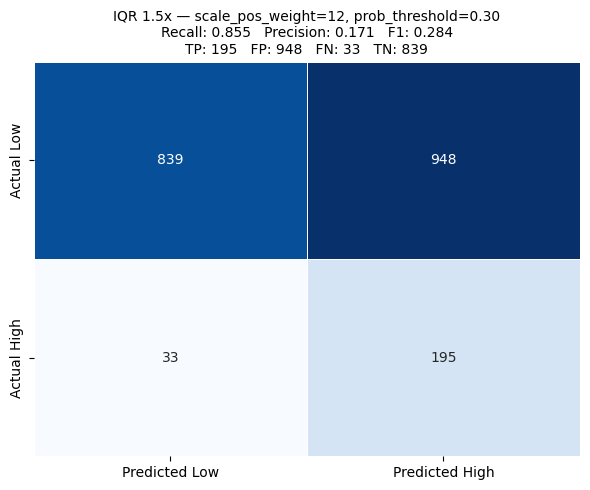

In [125]:
fig, ax = plt.subplots(figsize=(6, 5))

df = valid_sites.copy()
df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
df['HIGH_ABUNDANCE']   = (df['FEMALESCOLLECTED'] >= 23).astype(int)

n_low  = (df['HIGH_ABUNDANCE'] == 0).sum()
n_high = (df['HIGH_ABUNDANCE'] == 1).sum()
scale  = n_low / n_high

X      = df[log_feat_cols].copy()
y      = df['HIGH_ABUNDANCE']
groups = df['SITEID']

gkf = GroupKFold(n_splits=5)

all_y_true = []
all_y_pred = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
        scale_pos_weight=12,
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_weight=10,
        random_state=42,
        eval_metric='logloss',
        early_stopping_rounds=20,
        enable_categorical=True
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.30).astype(int)

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

# Metrics
cm = confusion_matrix(all_y_true, all_y_pred)
tn, fp, fn, tp = cm.ravel()
recall    = tp / (tp + fn)
precision = tp / (tp + fp)
f1        = 2 * (precision * recall) / (precision + recall)

cm_df = pd.DataFrame(
    cm,
    index=['Actual Low', 'Actual High'],
    columns=['Predicted Low', 'Predicted High']
)

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    cbar=False,
    ax=ax
)

ax.set_title(
    f'IQR 1.5x — scale_pos_weight=12, prob_threshold=0.30\n'
    f'Recall: {recall:.3f}   Precision: {precision:.3f}   F1: {f1:.3f}\n'
    f'TP: {tp}   FP: {fp}   FN: {fn}   TN: {tn}',
    fontsize=10
)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning
- Optuna tuned parameters maintained f1 floor at expense of a small reduction in recall. But it required 367 average trees -> could be overfitting to training folds.

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROB_THRESHOLD   = 0.30
ABUNDANCE_THRESH = 23
F1_FLOOR         = 0.481  # stratified random baseline

df = valid_sites.copy()
df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
df['HIGH_ABUNDANCE']   = (df['FEMALESCOLLECTED'] >= ABUNDANCE_THRESH).astype(int)

X      = df[log_feat_cols].copy()
y      = df['HIGH_ABUNDANCE']
groups = df['SITEID']

def objective(trial):
    params = {
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5.0, 20.0),
        'max_depth':        trial.suggest_int('max_depth', 2, 5),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20),
        'n_estimators':     500,
        'random_state':     42,
        'eval_metric':      'logloss',
        'early_stopping_rounds': 20,
        'enable_categorical':    True
    }

    gkf        = GroupKFold(n_splits=5)
    fold_recall = []
    fold_f1     = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = XGBClassifier(model_params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred  = (y_proba >= PROB_THRESHOLD).astype(int)

        fold_recall.append(recall_score(y_test, y_pred))
        fold_f1.append(f1_score(y_test, y_pred, average='macro'))

    mean_recall = np.mean(fold_recall)
    mean_f1     = np.mean(fold_f1)

    # Penalize trials that fall below F1 floor
    if mean_f1 < F1_FLOOR:
        return 0.0  # invalid trial — return worst possible score

    return mean_recall

# --- Run the study ---
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

# --- Results ---
print(f"\nBest recall:  {study.best_value:.3f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# --- Top 10 trials ---
trials_df = study.trials_dataframe()
valid_trials = trials_df[trials_df['value'] > 0].sort_values('value', ascending=False)
print(f"\nTop 10 valid trials:")
print(valid_trials[['number', 'value'] + 
      [c for c in trials_df.columns if 'params' in c]].head(10).to_string(index=False))

Python(64584) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Best trial: 24. Best value: 0.854895: 100%|██████████| 50/50 [01:19<00:00,  1.59s/it]


Best recall:  0.855
Best params:
  scale_pos_weight: 17.17821477504061
  max_depth: 4
  learning_rate: 0.017093866456306638
  subsample: 0.5332913648368347
  colsample_bytree: 0.7188552216582508
  min_child_weight: 10

Top 10 valid trials:
 number    value  params_colsample_bytree  params_learning_rate  params_max_depth  params_min_child_weight  params_scale_pos_weight  params_subsample
     24 0.854895                 0.718855              0.017094                 4                       10                17.178215          0.533291
     12 0.846661                 0.803509              0.010432                 4                        5                15.472326          0.633124
     11 0.844595                 0.740749              0.010929                 4                        5                15.407380          0.651842
      9 0.844330                 0.518091              0.012260                 5                       10                13.968500          0.578393
     40 0

### Compare Optuna to manual tuning

In [130]:
optuna_params = {
    'scale_pos_weight':      17.178,
    'max_depth':             4,
    'learning_rate':         0.017,
    'subsample':             0.533,
    'colsample_bytree':      0.719,
    'min_child_weight':      10,
    'n_estimators':          500,
    'random_state':          42,
    'eval_metric':           'logloss',
    'early_stopping_rounds': 20,
    'enable_categorical':    True
}

manual_params = {
    'scale_pos_weight':      12,
    'max_depth':             3,
    'learning_rate':         0.05,
    'subsample':             0.7,
    'colsample_bytree':      0.7,
    'min_child_weight':      10,
    'n_estimators':          500,
    'random_state':          42,
    'eval_metric':           'logloss',
    'early_stopping_rounds': 20,
    'enable_categorical':    True
}

results = []
results.append(run_xgb_recall(
    valid_sites, log_feat_cols, iqr_threshold,
    'Optuna best', prob_threshold=0.30,
    model_params=optuna_params
))
results.append(run_xgb_recall(
    valid_sites, log_feat_cols, iqr_threshold,
    'Manual tuned', prob_threshold=0.30,
    model_params=manual_params
))

results_df = pd.DataFrame(results)[[
    'threshold_name', 'prob_threshold', 'mean_recall',
    'mean_precision', 'mean_f1', 'mean_roc_auc'
]]
for col in ['mean_recall', 'mean_precision', 'mean_f1', 'mean_roc_auc']:
    results_df[col] = results_df[col].round(3)
print(results_df.to_string(index=False))


Threshold: Optuna best (>= 23 females)
Prob threshold: 0.3
High: 228 (11%)  Low: 1787 (89%)
scale_pos_weight: 17.2
  Fold 1 — Recall: 0.661  Precision: 0.233  Macro F1: 0.555  ROC-AUC: 0.668  trees: 361
  Fold 2 — Recall: 0.878  Precision: 0.162  Macro F1: 0.397  ROC-AUC: 0.783  trees: 192
  Fold 3 — Recall: 0.865  Precision: 0.164  Macro F1: 0.495  ROC-AUC: 0.766  trees: 435
  Fold 4 — Recall: 0.926  Precision: 0.113  Macro F1: 0.427  ROC-AUC: 0.847  trees: 438
  Fold 5 — Recall: 0.881  Precision: 0.274  Macro F1: 0.575  ROC-AUC: 0.832  trees: 411

  Mean Recall:    0.842 (+/- 0.093)
  Mean Precision: 0.189 (+/- 0.057)
  Mean Macro F1:  0.490 (+/- 0.069)
  Mean ROC-AUC:   0.779 (+/- 0.063)
  Avg best trees: 367

Threshold: Manual tuned (>= 23 females)
Prob threshold: 0.3
High: 228 (11%)  Low: 1787 (89%)
scale_pos_weight: 12.0
  Fold 1 — Recall: 0.732  Precision: 0.200  Macro F1: 0.496  ROC-AUC: 0.666  trees: 77
  Fold 2 — Recall: 0.918  Precision: 0.156  Macro F1: 0.359  ROC-AUC: 0.7

## XGB Prob

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done


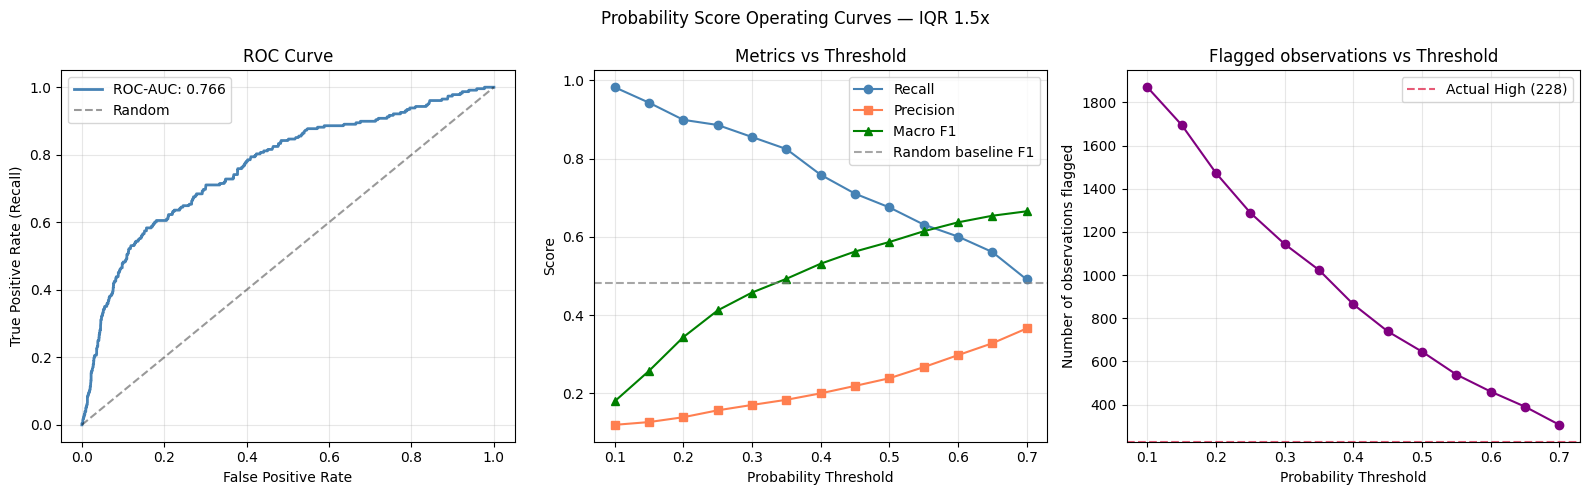


Threshold    Recall     Precision    Macro F1   Flagged   
------------------------------------------------------
0.10         0.982      0.120        0.180      1870      
0.15         0.943      0.127        0.258      1695      
0.20         0.899      0.139        0.344      1472      
0.25         0.886      0.157        0.412      1288      
0.30         0.855      0.171        0.458      1143      
0.35         0.825      0.184        0.493      1023       <-- above baseline
0.40         0.759      0.200        0.531      864        <-- above baseline
0.45         0.711      0.219        0.563      739        <-- above baseline
0.50         0.675      0.239        0.587      645        <-- above baseline
0.55         0.632      0.267        0.614      539        <-- above baseline
0.60         0.601      0.298        0.637      460        <-- above baseline
0.65         0.561      0.328        0.654      390        <-- above baseline
0.70         0.491      0.366        0.665  

In [133]:


df = valid_sites.copy()
df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
df['HIGH_ABUNDANCE']   = (df['FEMALESCOLLECTED'] >= 23).astype(int)

n_low  = (df['HIGH_ABUNDANCE'] == 0).sum()
n_high = (df['HIGH_ABUNDANCE'] == 1).sum()

X      = df[log_feat_cols].copy()
y      = df['HIGH_ABUNDANCE']
groups = df['SITEID']

gkf = GroupKFold(n_splits=5)

all_y_true  = []
all_y_proba = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBClassifier(
    scale_pos_weight=12,
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20,
    enable_categorical=True
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    all_y_true.extend(y_test.tolist())
    all_y_proba.extend(model.predict_proba(X_test)[:, 1].tolist())
    print(f"Fold {fold+1} done")

all_y_true  = np.array(all_y_true)
all_y_proba = np.array(all_y_proba)

# --- ROC curve ---
fpr, tpr, thresholds = roc_curve(all_y_true, all_y_proba)
roc_auc = roc_auc_score(all_y_true, all_y_proba)

# --- Precision-Recall at each threshold ---
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_range = np.arange(0.10, 0.71, 0.05)
results = []

for t in threshold_range:
    y_pred     = (all_y_proba >= t).astype(int)
    recall     = recall_score(all_y_true, y_pred)
    precision  = precision_score(all_y_true, y_pred, zero_division=0)
    f1         = f1_score(all_y_true, y_pred, average='macro')
    n_flagged  = y_pred.sum()
    results.append({
        'threshold': t,
        'recall':    recall,
        'precision': precision,
        'f1':        f1,
        'n_flagged': n_flagged
    })

results_df = pd.DataFrame(results)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — ROC curve
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC-AUC: {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2 — Recall, Precision, F1 vs threshold
axes[1].plot(results_df['threshold'], results_df['recall'],    'o-', color='steelblue', label='Recall')
axes[1].plot(results_df['threshold'], results_df['precision'], 's-', color='coral',     label='Precision')
axes[1].plot(results_df['threshold'], results_df['f1'],        '^-', color='green',     label='Macro F1')
axes[1].axhline(y=0.481, color='gray', linestyle='--', alpha=0.7, label='Random baseline F1')
axes[1].set_xlabel('Probability Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Metrics vs Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3 — Number of sites flagged vs threshold
axes[2].plot(results_df['threshold'], results_df['n_flagged'], 'o-', color='purple')
axes[2].axhline(y=n_high, color='crimson', linestyle='--', alpha=0.7, label=f'Actual High ({n_high})')
axes[2].set_xlabel('Probability Threshold')
axes[2].set_ylabel('Number of observations flagged')
axes[2].set_title('Flagged observations vs Threshold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Probability Score Operating Curves — IQR 1.5x', fontsize=12)
plt.tight_layout()
plt.show()

# --- Print threshold table ---
print(f"\n{'Threshold':<12} {'Recall':<10} {'Precision':<12} {'Macro F1':<10} {'Flagged':<10}")
print("-" * 54)
for _, row in results_df.iterrows():
    marker = ' <-- above baseline' if row['f1'] >= 0.481 else ''
    print(f"{row['threshold']:<12.2f} {row['recall']:<10.3f} {row['precision']:<12.3f} "
          f"{row['f1']:<10.3f} {int(row['n_flagged']):<10}{marker}")

## XGB Raw Prob 

### Final Model

In [ ]:
# Final training data
df = valid_sites.copy()
df['COLLECTTIMEOFDAY'] = df['COLLECTTIMEOFDAY'].astype('category')
df['HIGH_ABUNDANCE']   = (df['FEMALESCOLLECTED'] >= 23).astype(int)

n_low  = (df['HIGH_ABUNDANCE'] == 0).sum()
n_high = (df['HIGH_ABUNDANCE'] == 1).sum()

X_final = df[log_feat_cols].copy()
y_final = df['HIGH_ABUNDANCE']

final_model = XGBClassifier(
    scale_pos_weight=12,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    n_estimators=127,        # avg best trees from CV
    random_state=42,
    eval_metric='logloss',
    enable_categorical=True
)

final_model.fit(X_final, y_final)
print("Model trained successfully")

# Save model and feature cols
joblib.dump(final_model, 'mosquito_model.pkl')
joblib.dump(log_feat_cols, 'feature_cols.pkl')
print("Model saved to mosquito_model.pkl")
print("Feature cols saved to feature_cols.pkl")

Model trained successfully
Model saved to mosquito_model.pkl
Feature cols saved to feature_cols.pkl


### Prediction Function

In [153]:
def predict_abundance(
    latitude,
    longitude,
    collect_time_of_day,    # 'Morning' or 'Afternoon'
    tavg, tmax, tmin,
    prcp,
    tavg_lag7d, tavg_lag14d, tavg_lag21d,
    prcp_lag7d, prcp_lag14d, prcp_lag21d,
    tavg_roll7, tavg_roll14, prcp_roll7,
    twi,
    day_of_year, week, month,
    cum_degree_days, wet_days_14d, days_since_rain,
    temp_x_precip_7d, temp_x_precip_14d,
    temp_range, temp_range_roll7,
    model_path='mosquito_model.pkl',
    feat_cols_path='feature_cols.pkl'
):
    """
    Returns probability (0-1) of High mosquito abundance
    for a given location, date, and weather conditions.
    
    High abundance is defined as >= 23 females collected.
    A score of 0.82 means 82% probability of High abundance.
    """
    
    # Load model and feature cols
    model     = joblib.load(model_path)
    feat_cols = joblib.load(feat_cols_path)
    
    # Apply log transforms to match training data
    prcp_log        = np.log1p(prcp)
    prcp_lag7d_log  = np.log1p(prcp_lag7d)
    prcp_lag14d_log = np.log1p(prcp_lag14d)
    prcp_lag21d_log = np.log1p(prcp_lag21d)
    prcp_roll7_log  = np.log1p(prcp_roll7)
    twi_log         = np.log1p(twi)
    
    # Build input dataframe — must match training feature order exactly
    input_df = pd.DataFrame([{
        'LATITUDE':           latitude,
        'LONGITUDE':          longitude,
        'TWI_log':            twi_log,
        'TAVG':               tavg,
        'TMAX':               tmax,
        'TMIN':               tmin,
        'PRCP_log':           prcp_log,
        'TAVG_lag7d':         tavg_lag7d,
        'TAVG_lag14d':        tavg_lag14d,
        'TAVG_lag21d':        tavg_lag21d,
        'PRCP_lag7d_log':     prcp_lag7d_log,
        'PRCP_lag14d_log':    prcp_lag14d_log,
        'PRCP_lag21d_log':    prcp_lag21d_log,
        'TAVG_roll7':         tavg_roll7,
        'TAVG_roll14':        tavg_roll14,
        'PRCP_roll7_log':     prcp_roll7_log,
        'cum_degree_days':    cum_degree_days,
        'wet_days_14d':       wet_days_14d,
        'days_since_rain':    days_since_rain,
        'temp_x_precip_7d':   temp_x_precip_7d,
        'temp_x_precip_14d':  temp_x_precip_14d,
        'temp_range':         temp_range,
        'temp_range_roll7':   temp_range_roll7,
        'day_of_year':        day_of_year,
        'week':               week,
        'month':              month,
        'COLLECTTIMEOFDAY':   collect_time_of_day
    }])
    
    # Match dtypes to training data
    input_df['COLLECTTIMEOFDAY'] = input_df['COLLECTTIMEOFDAY'].astype('category')
    
    # Ensure column order matches training
    input_df = input_df[feat_cols]
    
    # Predict
    proba = model.predict_proba(input_df)[0, 1]
    
    return round(float(proba), 3)

### Final Test

In [155]:
# Example — site 18 in peak mosquito season (August)
# with warm, wet conditions
prob = predict_abundance(
    latitude=38.920,
    longitude=-77.030,
    collect_time_of_day='Morning',
    tavg=28.0,
    tmax=33.0,
    tmin=23.0,
    prcp=15.0,
    tavg_lag7d=27.5,
    tavg_lag14d=26.0,
    tavg_lag21d=25.0,
    prcp_lag7d=12.0,
    prcp_lag14d=8.0,
    prcp_lag21d=5.0,
    tavg_roll7=27.0,
    tavg_roll14=26.5,
    prcp_roll7=10.0,
    twi=5.2,
    day_of_year=220,
    week=32,
    month=8,
    cum_degree_days=1200,
    wet_days_14d=6,
    days_since_rain=1,
    temp_x_precip_7d=27.0 * np.log1p(10.0),
    temp_x_precip_14d=26.5 * np.log1p(10.0),
    temp_range=10.0,
    temp_range_roll7=9.5
)

print(f"Probability of High abundance: {prob}")
print(f"Interpretation: {prob*100:.1f}% chance of >= 23 females collected")

Probability of High abundance: 0.211
Interpretation: 21.1% chance of >= 23 females collected


In [154]:
# Shared spatial params — mid DC location
LAT       = 38.920
LON       = -77.030
TWI       = 5.2

# Does the model predict High for a cold dry July day?
prob_cold_july = predict_abundance(
    latitude=LAT,
    longitude=LON,
    collect_time_of_day='Morning',
    tavg=15.0,           # unusually cold
    tmax=18.0,
    tmin=12.0,
    prcp=0.0,            # dry
    prcp_lag7d=0.0,
    prcp_lag14d=0.0,
    prcp_lag21d=0.0,
    tavg_lag7d=14.0,     # consistently cold week prior
    tavg_lag14d=13.0,
    tavg_lag21d=12.0,
    tavg_roll7=14.5,
    tavg_roll14=13.5,
    prcp_roll7=0.0,      # dry stretch
    twi=TWI,
    day_of_year=210,
    week=30,
    month=7,
    cum_degree_days=400,  # low — cold summer
    wet_days_14d=0,       # no rain in 2 weeks
    days_since_rain=14,
    temp_x_precip_7d=14.5  * np.log1p(0.0),
    temp_x_precip_14d=13.5 * np.log1p(0.0),
    temp_range=6.0,
    temp_range_roll7=6.0
)

# Compare to warm wet July day
prob_warm_july = predict_abundance(
    latitude=LAT,
    longitude=LON,
    collect_time_of_day='Morning',
    tavg=30.0,           # hot
    tmax=35.0,
    tmin=25.0,
    prcp=20.0,           # wet
    prcp_lag7d=15.0,
    prcp_lag14d=10.0,
    prcp_lag21d=8.0,
    tavg_lag7d=29.0,     # consistently warm week prior
    tavg_lag14d=28.0,
    tavg_lag21d=27.0,
    tavg_roll7=29.5,
    tavg_roll14=28.5,
    prcp_roll7=12.0,     # sustained wet period
    twi=TWI,
    day_of_year=210,
    week=30,
    month=7,
    cum_degree_days=1400, # high — hot summer
    wet_days_14d=8,       # 8 wet days in past 2 weeks
    days_since_rain=1,
    temp_x_precip_7d=29.5  * np.log1p(12.0),
    temp_x_precip_14d=28.5 * np.log1p(12.0),
    temp_range=10.0,
    temp_range_roll7=9.5
)

print(f"Cold dry July probability:  {prob_cold_july}")
print(f"Warm wet July probability:  {prob_warm_july}")
print(f"Difference:                 {prob_warm_july - prob_cold_july:.3f}")
print(f"\nInterpretation:")
if prob_warm_july - prob_cold_july > 0.15:
    print("  Model is correctly responding to weather conditions on top of seasonality")
elif prob_warm_july - prob_cold_july > 0.05:
    print("  Model shows modest weather sensitivity — day_of_year is dominant")
else:
    print("  Model is largely ignoring weather — day_of_year is too dominant")

Cold dry July probability:  0.28
Warm wet July probability:  0.135
Difference:                 -0.145

Interpretation:
  Model is largely ignoring weather — day_of_year is too dominant


In [156]:
print(valid_sites[['day_of_year', 'TAVG', 'cum_degree_days', 
                    'TAVG_roll7', 'TAVG_roll14']].corr().round(2))

                 day_of_year  TAVG  cum_degree_days  TAVG_roll7  TAVG_roll14
day_of_year             1.00  0.11             0.90        0.14         0.25
TAVG                    0.11  1.00            -0.01        0.83         0.77
cum_degree_days         0.90 -0.01             1.00        0.04         0.15
TAVG_roll7              0.14  0.83             0.04        1.00         0.94
TAVG_roll14             0.25  0.77             0.15        0.94         1.00


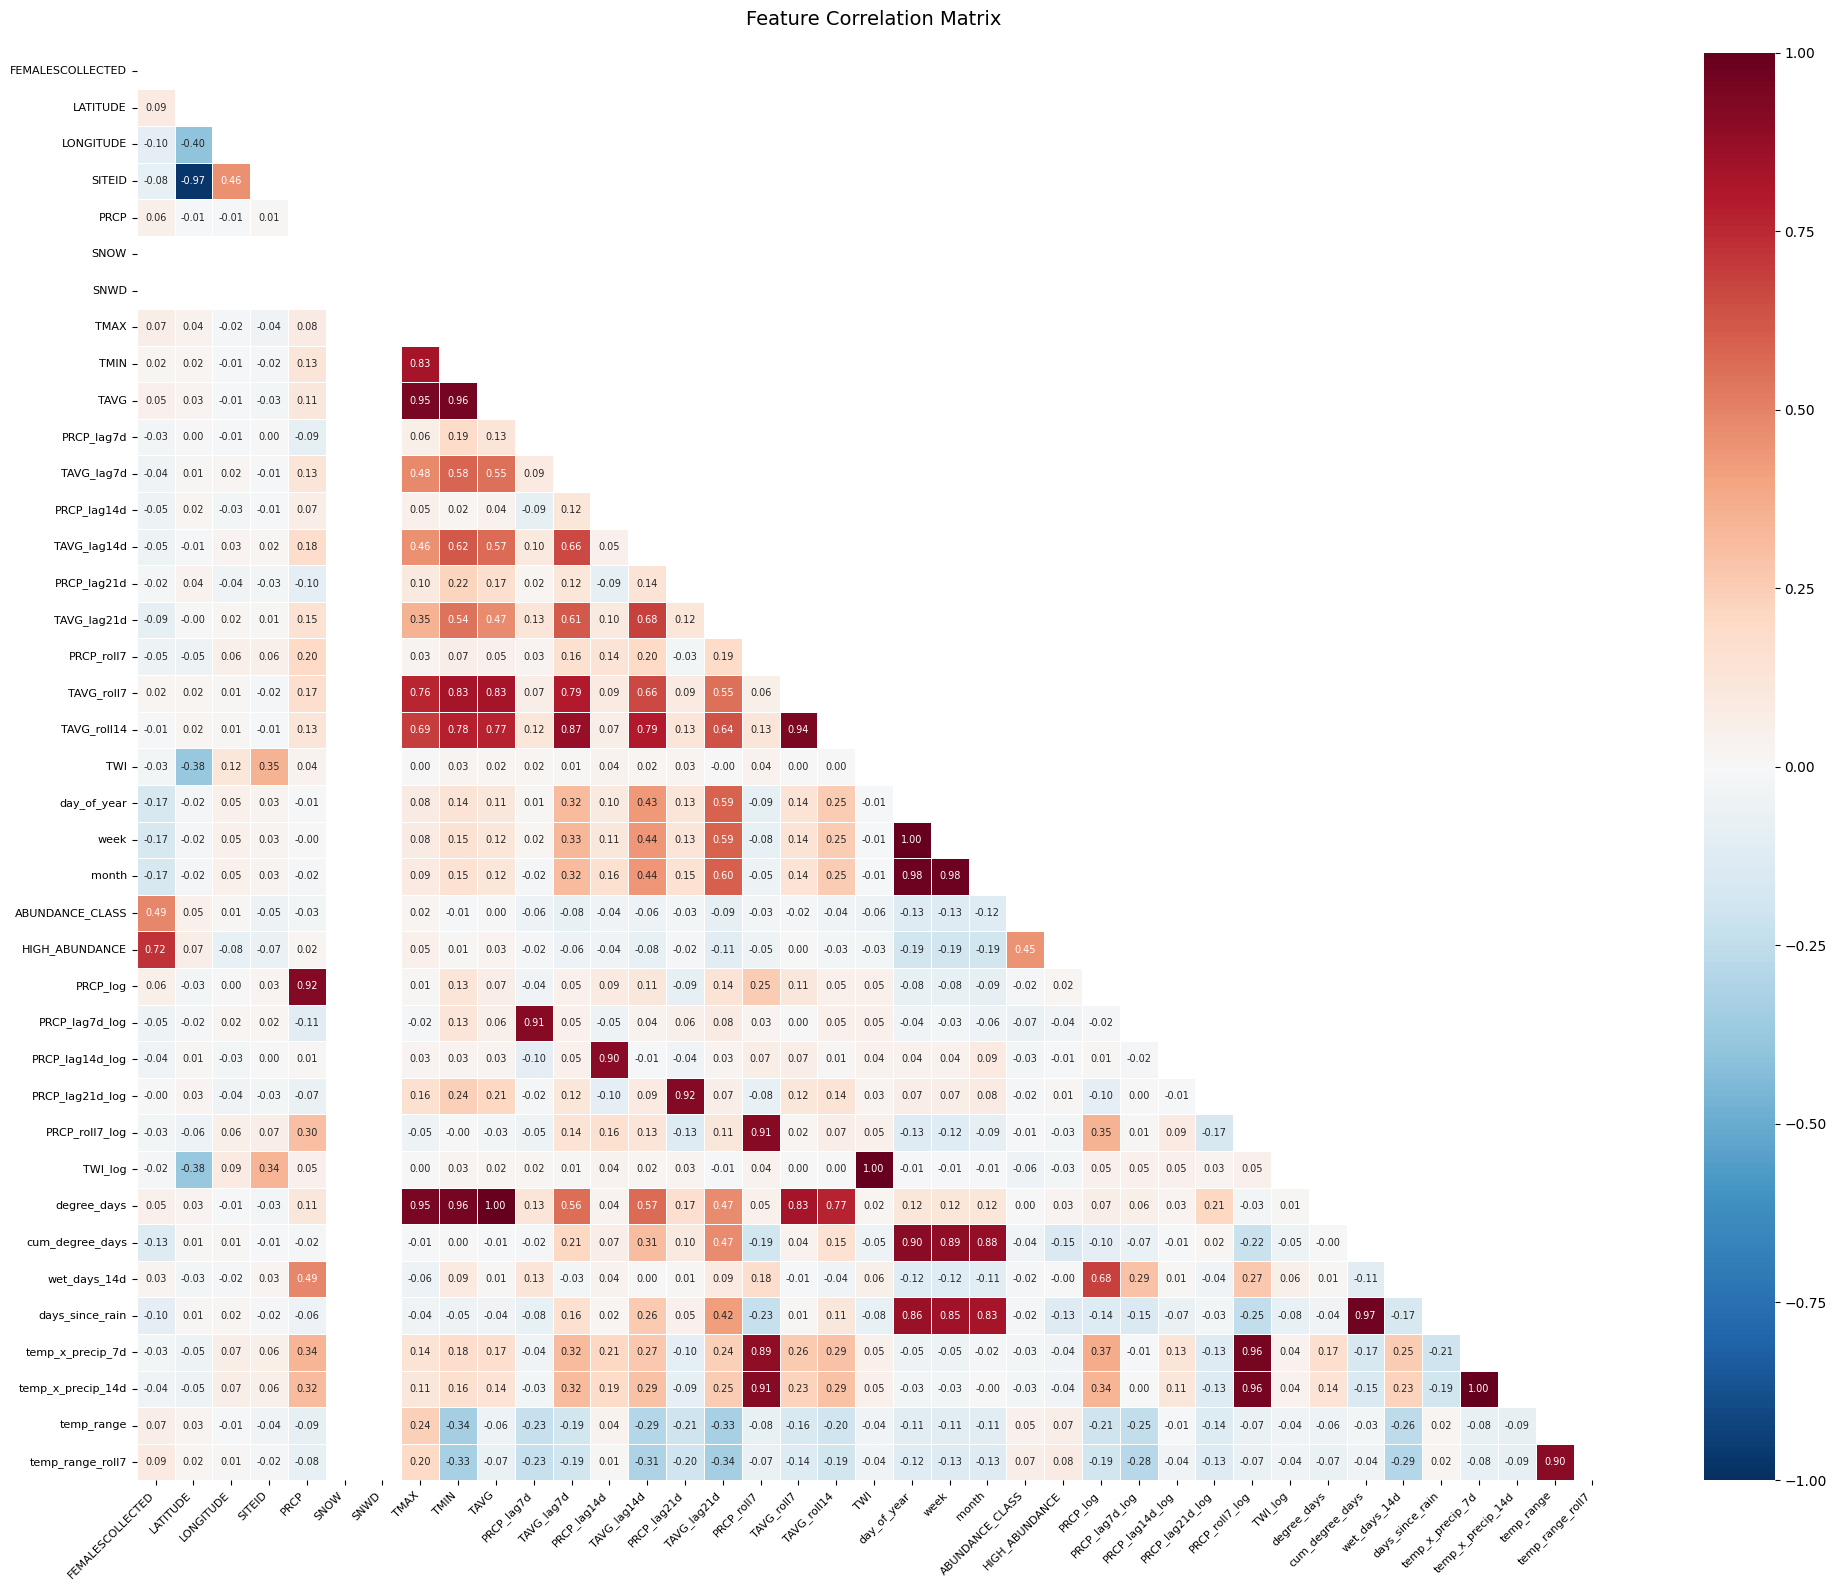


Highly correlated pairs (|r| > 0.80):
--------------------------------------------------
       Feature 1         Feature 2  Correlation
             TWI           TWI_log         1.00
temp_x_precip_7d temp_x_precip_14d         1.00
            TAVG       degree_days         1.00
     day_of_year              week         1.00
            week             month         0.98
     day_of_year             month         0.98
        LATITUDE            SITEID        -0.97
 cum_degree_days   days_since_rain         0.97
            TMIN              TAVG         0.96
            TMIN       degree_days         0.96
  PRCP_roll7_log temp_x_precip_14d         0.96
  PRCP_roll7_log  temp_x_precip_7d         0.96
            TMAX              TAVG         0.95
            TMAX       degree_days         0.95
      TAVG_roll7       TAVG_roll14         0.94
            PRCP          PRCP_log         0.92
     PRCP_lag21d   PRCP_lag21d_log         0.92
      PRCP_roll7 temp_x_precip_14d         0.9

In [161]:
# Select only numeric columns
numeric_cols = valid_sites.select_dtypes(include=[np.number]).columns.tolist()

# Drop target and ID columns
#numeric_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = valid_sites[numeric_cols].corr().round(2)

# Plot
fig, ax = plt.subplots(figsize=(20, 16))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Print highly correlated pairs (> 0.80 or < -0.80)
print("\nHighly correlated pairs (|r| > 0.80):")
print("-" * 50)
pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.80:
            pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                r
            ))

pairs_df = pd.DataFrame(pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
pairs_df = pairs_df.reindex(pairs_df['Correlation'].abs().sort_values(ascending=False).index)
print(pairs_df.to_string(index=False))

## Additional Plots

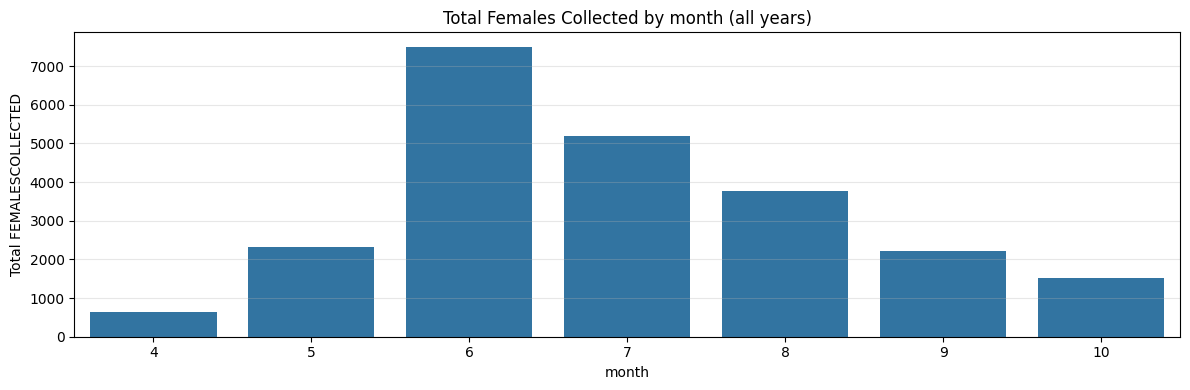

In [147]:
# Aggregate total females by ISO week and plot
monthly_sum = valid_sites.groupby('month')['FEMALESCOLLECTED'].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(x=monthly_sum.index.astype(int), y=monthly_sum.values, color='C0', ax=ax)

ax.set_xlabel('month')
ax.set_ylabel('Total FEMALESCOLLECTED')
ax.set_title('Total Females Collected by month (all years)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

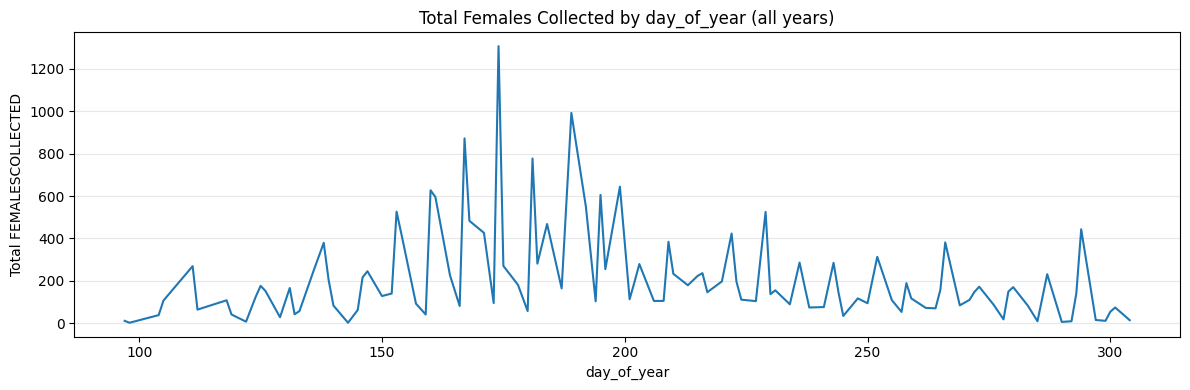

In [150]:
# Aggregate total females by ISO week and plot
daily_sum = valid_sites.groupby('day_of_year')['FEMALESCOLLECTED'].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(x=daily_sum.index.astype(int), y=daily_sum.values, color='C0', ax=ax)

ax.set_xlabel('day_of_year')
ax.set_ylabel('Total FEMALESCOLLECTED')
ax.set_title('Total Females Collected by day_of_year (all years)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()